# DermaSight
Intelligent Skin Disease Classification & Severity Scoring System

Sumber data
[Kaggle Isic 2019](https://www.kaggle.com/datasets/andrewmvd/isic-2019?resource=download)

Dataset ISIC_2019 dipilih karena merupakan dataset benchmark internasional untuk klasifikasi penyakit kulit berbasis AI yang memiliki jumlah data besar, kualitas citra yang baik, serta metadata pendukung seperti usia, gender, dan anatomical site. Selain itu, dataset ini relevan untuk pengembangan sistem deteksi dini penyakit kulit pada proyek DermaSight.

# Business Understanding
## Latar Belakang

Penyakit kulit merupakan salah satu masalah kesehatan yang sering diabaikan karena kurangnya kesadaran masyarakat terhadap pentingnya deteksi dini. Di Indonesia, akses terhadap dokter spesialis kulit masih terbatas, khususnya di daerah non-perkotaan. Akibatnya, banyak masyarakat melakukan diagnosis mandiri yang berisiko memperburuk kondisi penyakit.

DermaSight dikembangkan sebagai sistem berbasis Artificial Intelligence yang mampu membantu proses klasifikasi penyakit kulit melalui citra lesi kulit. Selain melakukan klasifikasi, sistem juga dirancang untuk memberikan severity scoring sebagai indikator tingkat keparahan awal untuk membantu proses triase.

## Business Questions

1. Bagaimana karakteristik distribusi Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) berdasarkan metadata pasien seperti usia, jenis kelamin, dan lokasi anatomi lesi?

2. Apakah terdapat ketidakseimbangan distribusi kelas (class imbalance) pada dataset Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) yang dapat mempengaruhi performa model klasifikasi AI?

3. Bagaimana kualitas dan karakteristik citra medis pada dataset Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) yang akan digunakan untuk pengembangan model klasifikasi kanker kulit berbasis AI?

4. Bagaimana proses preprocessing dan feature engineering membantu meningkatkan kualitas dataset serta mendukung analisis karakteristik Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC)?


# Import Library

In [60]:
# File and system utilities
import os
import cv2
import warnings
import shutil

# Data processing
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# File and image processing
from pathlib import Path
from PIL import Image

# Class distribution analysis
from collections import Counter

# Machine learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ignore warnings
warnings.filterwarnings('ignore')

# Visualization setup
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Library loaded successfully.")

Library loaded successfully.


# Data Wrangling

## Gathering Data

In [3]:
#Install Kaggle di Colab
!pip install kaggle

In [4]:
#Upload Kaggle API
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "sindiprassetiyani",\r\n  "key": "KGAT_73052c3e4f5d6cbd49ca18551cbb39bd"\r\n}\r\n'}

In [5]:
# Setup Kaggle API
os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
#Download Dataset
!kaggle datasets download -d andrewmvd/isic-2019

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:16<00:00, 127MB/s]



In [7]:
#Extract Dataset
!unzip isic-2019.zip -d isic_2019

Streaming output truncated to the last 5000 lines.
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065358.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065359.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065360.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065361.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065362.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065366.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065367.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065368.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065370.jpg  
  inflating: isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0065371.jpg  
  inflating: isic_2019/ISIC_2

In [8]:
#Cek Isi Dataset
os.listdir('isic_2019')

['ISIC_2019_Training_GroundTruth.csv',
 'ISIC_2019_Training_Metadata.csv',
 'ISIC_2019_Training_Input']

In [9]:
#Hubungkan ke GDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
#Buat Folder Project di Drive
BASE_PATH = "/content/drive/MyDrive/DermaSight-DS"

os.makedirs(BASE_PATH, exist_ok=True)

print("Folder project created.")

Folder project created.


In [11]:
#Copy Dataset ke Drive
!cp -r isic_2019 "/content/drive/MyDrive/DermaSight-DS/"

In [12]:
#Cek Dataset ke Drive
os.listdir("/content/drive/MyDrive/DermaSight-DS")

['isic_2019']

In [13]:
#Cek Dataset ke Drive
os.listdir("/content/drive/MyDrive/DermaSight-DS/isic_2019")

['ISIC_2019_Training_GroundTruth.csv',
 'ISIC_2019_Training_Input',
 'ISIC_2019_Training_Metadata.csv']

In [14]:
# Set PATH
BASE_PATH = "/content/drive/MyDrive/DermaSight-DS/isic_2019"

METADATA_PATH = f"{BASE_PATH}/ISIC_2019_Training_Metadata.csv"

GROUNDTRUTH_PATH = f"{BASE_PATH}/ISIC_2019_Training_GroundTruth.csv"

IMAGE_PATH = f"{BASE_PATH}/ISIC_2019_Training_Input/ISIC_2019_Training_Input"

print("Metadata Path:")
print(METADATA_PATH)

print("\nGroundtruth Path:")
print(GROUNDTRUTH_PATH)

print("\nImage Folder Path:")
print(IMAGE_PATH)

Metadata Path:
/content/drive/MyDrive/DermaSight-DS/isic_2019/ISIC_2019_Training_Metadata.csv

Groundtruth Path:
/content/drive/MyDrive/DermaSight-DS/isic_2019/ISIC_2019_Training_GroundTruth.csv

Image Folder Path:
/content/drive/MyDrive/DermaSight-DS/isic_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input


In [15]:
#Load Metadata

metadata_df = pd.read_csv(METADATA_PATH)

print("Metadata loaded successfully.")

Metadata loaded successfully.


In [16]:
# Load Groundtruth

groundtruth_df = pd.read_csv(GROUNDTRUTH_PATH)

print("Groundtruth loaded successfully.")

Groundtruth loaded successfully.


In [17]:
#Cek Shape
print("Metadata Shape :", metadata_df.shape)
print("Groundtruth Shape :", groundtruth_df.shape)

Metadata Shape : (25331, 5)
Groundtruth Shape : (25331, 10)


In [18]:
#Sample Data m
metadata_df.head()

,image,age_approx,anatom_site_general,lesion_id,sex
0,ISIC_0000000,55.0,anterior torso,NaN,female
1,ISIC_0000001,30.0,anterior torso,NaN,female
2,ISIC_0000002,60.0,upper extremity,NaN,female
3,ISIC_0000003,30.0,upper extremity,NaN,male
4,ISIC_0000004,80.0,posterior torso,NaN,male


In [19]:
#Sample Data g
groundtruth_df.head()

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Insight:**

- Dataset terdiri dari 25.331 metadata pasien dan 25.331 label klasifikasi penyakit kulit sehingga jumlah data antar tabel sudah konsisten dan siap untuk proses merging.

- Metadata berisi kombinasi fitur numerik dan kategorikal seperti usia pasien, jenis kelamin, dan lokasi anatomi lesi yang berpotensi digunakan sebagai fitur tambahan untuk severity scoring.

- Groundtruth menggunakan pendekatan one-hot encoding pada label penyakit, yang umum digunakan pada pipeline klasifikasi multiclass dalam computer vision dan medical imaging.

- Keberadaan kelas seperti MEL (Melanoma) dan NV (Melanocytic Nevus) menunjukkan bahwa dataset mencakup kasus benign maupun malignant sehingga cocok digunakan untuk pengembangan sistem deteksi dini penyakit kulit.

In [20]:
# Merge Metadata & Groundtruth
df = metadata_df.merge(
    groundtruth_df,
    on='image',
    how='inner'
)

print("Merged dataset shape:", df.shape)

Merged dataset shape: (25331, 14)


In [21]:
df.head()

,image,age_approx,anatom_site_general,lesion_id,sex,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,55.0,anterior torso,NaN,female,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,30.0,anterior torso,NaN,female,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,60.0,upper extremity,NaN,female,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,30.0,upper extremity,NaN,male,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,80.0,posterior torso,NaN,male,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Create Target Label

label_columns = [
    'MEL', 'NV', 'BCC', 'AK',
    'BKL', 'DF', 'VASC', 'SCC', 'UNK'
]

df['target'] = df[label_columns].idxmax(axis=1)

print("Target label created successfully.")

Target label created successfully.


In [23]:
df[['image', 'target']].head()

,image,target
0,ISIC_0000000,NV
1,ISIC_0000001,NV
2,ISIC_0000002,MEL
3,ISIC_0000003,NV
4,ISIC_0000004,MEL


In [24]:
df['target'].unique()

array(['NV', 'MEL', 'BKL', 'DF', 'SCC', 'BCC', 'VASC', 'AK'], dtype=object)

In [25]:
print("Number of classes:", df['target'].nunique())

Number of classes: 8


**Insight:**

- Proses merging berhasil dilakukan menggunakan kolom image sebagai primary identifier antara metadata dan label klasifikasi.

- Inner join digunakan untuk memastikan hanya data yang memiliki pasangan metadata dan label yang dipertahankan dalam pipeline analisis.

- Label klasifikasi berhasil dikonversi dari format one-hot encoding menjadi single multiclass target menggunakan metode argmax.

- Pendekatan multiclass labeling umum digunakan pada medical image classification karena lebih efisien untuk proses preprocessing dan interpretasi model dibanding mempertahankan format one-hot pada tahap awal analisis.

## Data Assessing

In [26]:
# Dataset Shape

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(25331, 15)


In [27]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25331 entries, 0 to 25330
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   image                25331 non-null  object 
 1   age_approx           24894 non-null  float64
 2   anatom_site_general  22700 non-null  object 
 3   lesion_id            23247 non-null  object 
 4   sex                  24947 non-null  object 
 5   MEL                  25331 non-null  float64
 6   NV                   25331 non-null  float64
 7   BCC                  25331 non-null  float64
 8   AK                   25331 non-null  float64
 9   BKL                  25331 non-null  float64
 10  DF                   25331 non-null  float64
 11  VASC                 25331 non-null  float64
 12  SCC                  25331 non-null  float64
 13  UNK                  25331 non-null  float64
 14  target               25331 non-null  object 
dtypes: float64(10), object(5)
memory usa

In [28]:
# Missing Value Check

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': round((missing_values / len(df)) * 100, 2)
})

missing_df

,Missing Values,Percentage (%)
anatom_site_general,2631,10.39
lesion_id,2084,8.23
age_approx,437,1.73
sex,384,1.52
image,0,0.00
MEL,0,0.00
NV,0,0.00
BCC,0,0.00
AK,0,0.00
BKL,0,0.00


In [29]:
# Duplicate Check

duplicate_count = df.duplicated().sum()

print("Total Duplicate Data:", duplicate_count)

Total Duplicate Data: 0


In [30]:
# Image Validation Pipeline
# Create Image PAth

df['image_path'] = df['image'].apply(
    lambda x: os.path.join(
        IMAGE_PATH,
        f"{x}.jpg"
    )
)

df[['image', 'image_path']].head()


,image,image_path
0,ISIC_0000000,/content/drive/MyDrive/DermaSight-DS/isic_2019...
1,ISIC_0000001,/content/drive/MyDrive/DermaSight-DS/isic_2019...
2,ISIC_0000002,/content/drive/MyDrive/DermaSight-DS/isic_2019...
3,ISIC_0000003,/content/drive/MyDrive/DermaSight-DS/isic_2019...
4,ISIC_0000004,/content/drive/MyDrive/DermaSight-DS/isic_2019...


In [31]:
# Check Image Existence

df['image_exists'] = df['image_path'].apply(os.path.exists)

image_existence = df['image_exists'].value_counts()

image_existence

,count
image_exists,
True,25331


In [32]:
# Corrupted Image Validation

corrupted_images = []

for path in df['image_path']:

    try:
        img = Image.open(path)
        img.verify()

    except:
        corrupted_images.append(path)

print("Total Corrupted Images:", len(corrupted_images))

Total Corrupted Images: 0


**Insight:**

- Dataset ISIC 2019 terdiri dari 25.331 data citra kulit dengan total 17 kolom yang mencakup metadata pasien, label penyakit, serta informasi path gambar.

- Hasil pengecekan missing value menunjukkan bahwa beberapa kolom metadata seperti `anatom_site_general`, `lesion_id`, `age_approx`, dan `sex` masih memiliki nilai kosong dengan persentase tertinggi terdapat pada kolom `anatom_site_general` sebesar 10.39%.

- Dataset tidak memiliki duplicate data sehingga setiap baris data dianggap unik dan valid untuk proses analisis lebih lanjut.

- Validasi image path menunjukkan seluruh citra berhasil terhubung dengan dataset metadata dan seluruh file gambar dapat ditemukan pada direktori penyimpanan.

- Hasil corrupted image validation menunjukkan tidak terdapat file gambar yang rusak sehingga seluruh citra valid untuk digunakan pada proses preprocessing dan training model AI.

## Cleaning Data

- Missing value pada kolom `anatom_site_general` dan `sex` diisi menggunakan kategori `"unknown"` untuk mempertahankan jumlah data tanpa menghapus observasi penting pada dataset medis.

- Missing value pada kolom `age_approx` diisi menggunakan median karena median lebih stabil terhadap outlier dibandingkan rata-rata (mean).

- Pendekatan ini membantu menjaga kualitas dataset sebelum memasuki tahap exploratory data analysis dan preprocessing.

In [33]:
# Handle Missing Values

df_cleaned = df.copy()

# Fill anatomical site
df_cleaned['anatom_site_general'] = (
    df_cleaned['anatom_site_general']
    .fillna('unknown')
)

# Fill sex
df_cleaned['sex'] = (
    df_cleaned['sex']
    .fillna('unknown')
)

# Fill age
df_cleaned['age_approx'] = (
    df_cleaned['age_approx']
    .fillna(df_cleaned['age_approx'].median())
)

print("Missing value handling completed.")

Missing value handling completed.


In [34]:
df_cleaned.isnull().sum()

,0
image,0
age_approx,0
anatom_site_general,0
lesion_id,2084
sex,0
MEL,0
NV,0
BCC,0
AK,0
BKL,0


In [35]:
# lesion_id
missing_mask = df_cleaned['lesion_id'].isnull()

df_cleaned.loc[missing_mask, 'lesion_id'] = [
    f"unknown_lesion_{i}"
    for i in range(missing_mask.sum())
]

print("Missing lesion_id handled.")

Missing lesion_id handled.


- Missing value pada kolom `lesion_id` diisi menggunakan label `"unknown_lesion"` untuk mempertahankan jumlah data tanpa menghapus citra medis yang masih valid digunakan pada proses analisis.

- Pendekatan ini membantu menjaga konsistensi struktur dataset serta mempermudah proses identifikasi data yang sebelumnya tidak memiliki identifier lesi.

In [36]:
df_cleaned.isnull().sum()

,0
image,0
age_approx,0
anatom_site_general,0
lesion_id,0
sex,0
MEL,0
NV,0
BCC,0
AK,0
BKL,0


In [37]:
# Final Target Scope Cleaning
selected_classes = [

    'MEL',
    'NV',
    'BCC'
]

df_model = df_cleaned[

    df_cleaned['target']
    .isin(selected_classes)

].copy()

print("Filtered Dataset Shape:")
print(df_model.shape)

Filtered Dataset Shape:
(20720, 17)


In [38]:
# Cek Distribusi
df_model['target'].value_counts()

,count
target,
NV,12875
MEL,4522
BCC,3323


In [39]:
summary_df = pd.DataFrame({
    'Tahap': [
        'Raw Dataset',
        'After Cleaning',
        'After Class Filtering'
    ],

    'Jumlah Data': [
        len(df),
        len(df_cleaned),
        len(df_model)
    ],

    'Jumlah Class': [
        df['target'].nunique(),
        df_cleaned['target'].nunique(),
        df_model['target'].nunique()
    ],

    'Keterangan': [
        'Dataset asli ISIC_2019',
        'Missing value dan validasi data',
        'Fokus pada class MEL, NV, dan BCC'
    ]
})

summary_df

,Tahap,Jumlah Data,Jumlah Class,Keterangan
0,Raw Dataset,25331,8,Dataset asli ISIC_2019
1,After Cleaning,25331,8,Missing value dan validasi data
2,After Class Filtering,20720,3,"Fokus pada class MEL, NV, dan BCC"


Jumlah data pada tahap *Raw Dataset* dan *After Cleaning* tetap sama karena proses cleaning **tidak menghapus** baris data. Tahap cleaning dilakukan dengan menangani missing value menggunakan metode **imputasi** dan pengisian **nilai default**, seperti mengisi nilai unknown pada fitur kategorikal serta menggunakan median pada fitur usia `age_approx`. Selain itu, missing value pada `lesion_id` juga ditangani dengan pemberian identifier baru. Pengurangan jumlah data baru terjadi pada tahap *After Class Filtering* karena dataset difokuskan pada tiga kelas utama, yaitu MEL, NV, dan BCC.

**Insight:**
- Proses filtering target class dilakukan untuk menyederhanakan kompleksitas klasifikasi sekaligus memfokuskan model pada kategori lesi kulit yang paling relevan terhadap deteksi awal kanker kulit.

- Dataset difokuskan pada tiga kelas utama, yaitu MEL, NV, dan BCC karena memiliki relevansi tinggi dalam deteksi dini kanker kulit. Selain itu, pemfokusan pada tiga kelas membantu proses analisis dan pengembangan model menjadi lebih terarah serta mengurangi kompleksitas klasifikasi multi-class.

- Melanoma dan Basal Cell Carcinoma termasuk kategori lesi berisiko tinggi sehingga menjadi prioritas utama dalam pengembangan sistem klasifikasi kanker kulit.

- Pembatasan jumlah kelas membantu meningkatkan stabilitas training model dan mengurangi kompleksitas class imbalance pada medical imaging dataset.


# Exploratory Data Analysis (EDA)

## Univariate Analysis

In [40]:
# Target Variable Analysis

target_distribution = (
    df_model['target']
    .value_counts()
)

target_distribution

,count
target,
NV,12875
MEL,4522
BCC,3323


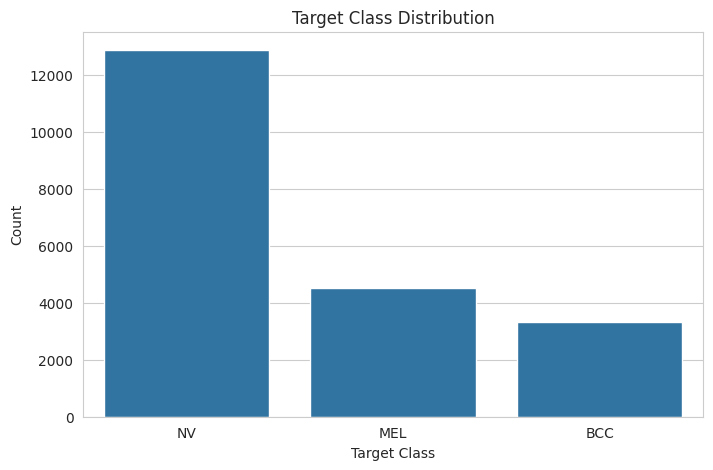

In [41]:
# Target Distwibution Visualization

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_model,

    x='target',

    order=df_model['target']
    .value_counts()
    .index
)

plt.title("Target Class Distribution")

plt.xlabel("Target Class")

plt.ylabel("Count")

plt.show()

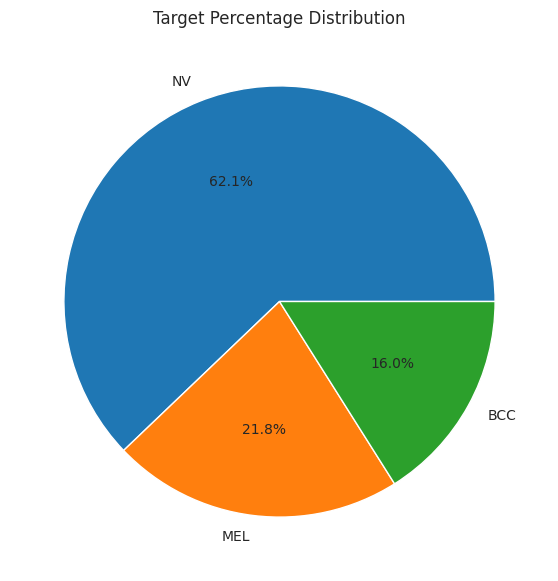

In [42]:
# Target Precentage Distribution

df_model['target'].value_counts().plot(

    kind='pie',

    autopct='%1.1f%%',

    figsize=(7,7)
)

plt.ylabel("")

plt.title("Target Percentage Distribution")

plt.show()

In [43]:
# Class Imbalance Analysis

class_counts = (
    df_model['target']
    .value_counts()
)

imbalance_ratio = round(

    class_counts.max() /

    class_counts.min(),

    2
)

print(
    "Imbalance Ratio:",
    imbalance_ratio
)

Imbalance Ratio: 3.87


In [44]:
# Numerical Data Analysis

df_model['age_approx'].describe()

,age_approx
count,20720.000000
mean,51.814431
std,17.847190
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


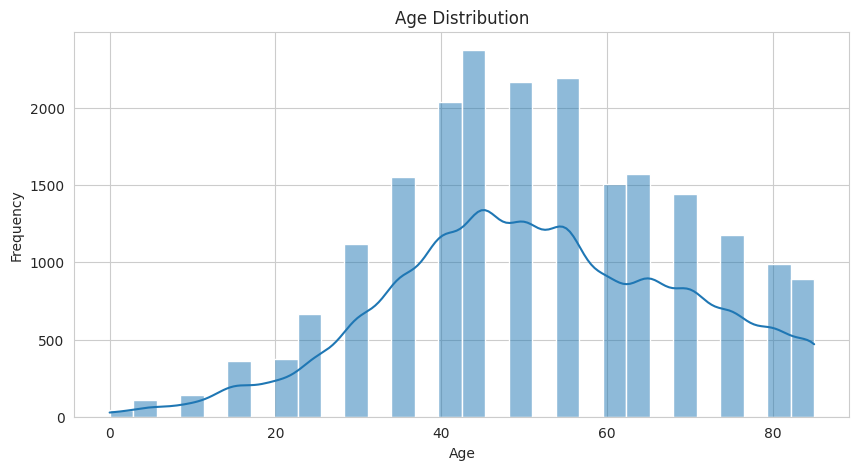

In [45]:
# Age Distribution

plt.figure(figsize=(10,5))

sns.histplot(

    df_model['age_approx'],

    bins=30,

    kde=True
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

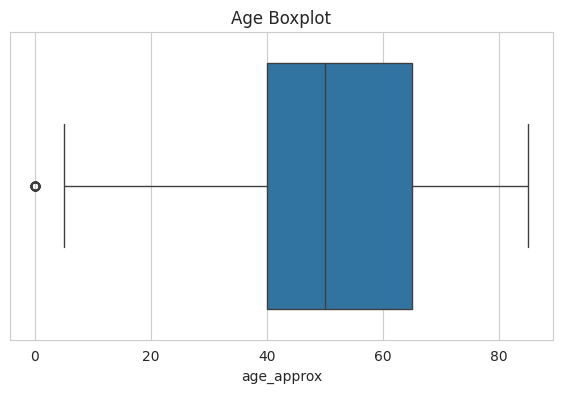

In [46]:
# Age Boxplot

plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_model['age_approx']
)

plt.title("Age Boxplot")

plt.show()

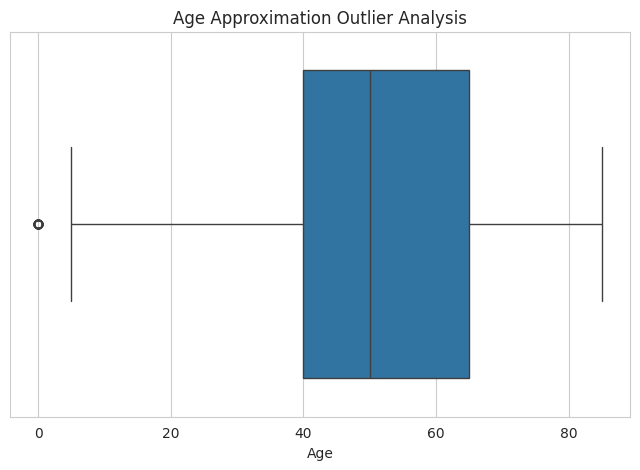

In [47]:
# Outlier Analysis

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_model['age_approx']
)

plt.title("Age Approximation Outlier Analysis")

plt.xlabel("Age")

plt.show()

In [48]:
# Sex Distribution

df_model['sex'].value_counts()

,count
sex,
male,10686
female,9676
unknown,358


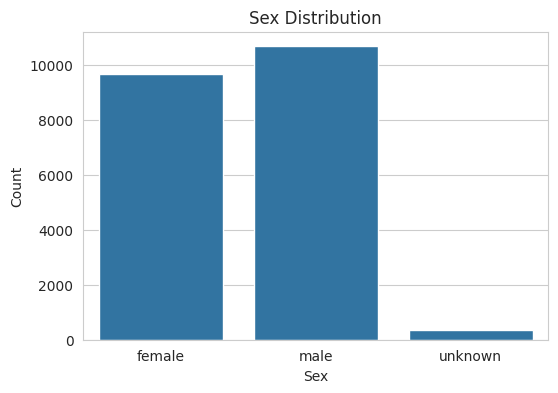

In [49]:
# Sex Distribution Visualization

plt.figure(figsize=(6,4))

sns.countplot(

    data=df_model,

    x='sex'
)

plt.title("Sex Distribution")

plt.xlabel("Sex")

plt.ylabel("Count")

plt.show()

In [50]:
# Anatomical Site Analysis

df_model['anatom_site_general'].value_counts()

,count
anatom_site_general,
anterior torso,6144
lower extremity,4134
head/neck,2778
posterior torso,2504
upper extremity,2407
unknown,2293
palms/soles,369
lateral torso,48
oral/genital,43


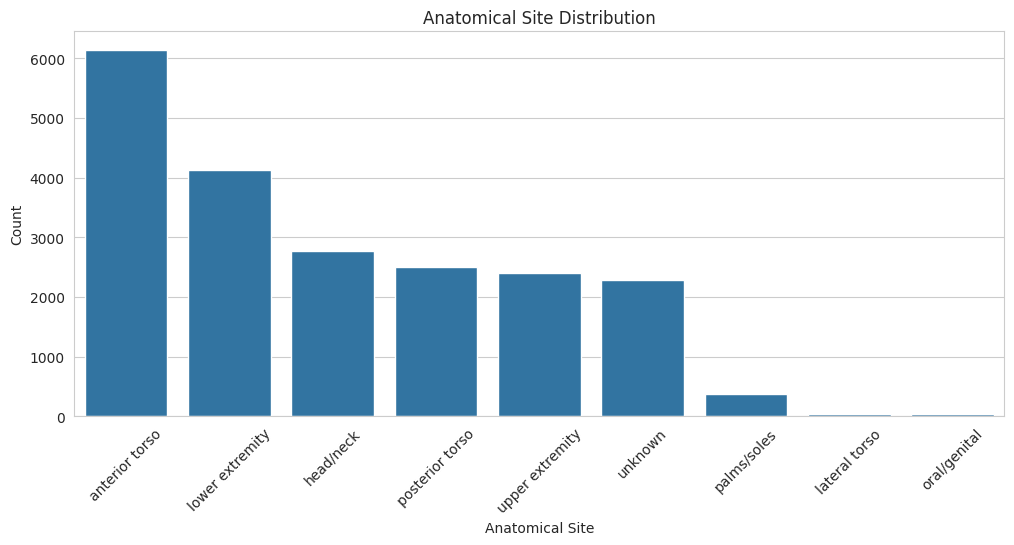

In [51]:
# Anatomical Site Visualization

plt.figure(figsize=(12,5))

sns.countplot(

    data=df_model,

    x='anatom_site_general',

    order=df_model['anatom_site_general']
    .value_counts()
    .index
)

plt.xticks(rotation=45)

plt.title("Anatomical Site Distribution")

plt.xlabel("Anatomical Site")

plt.ylabel("Count")

plt.show()

In [52]:
# Image Dimension Analysis

image_widths = []

image_heights = []

for path in df_model['image_path'][:1000]:

    img = Image.open(path)

    width, height = img.size

    image_widths.append(width)

    image_heights.append(height)

print(
    "Total analyzed images:",
    len(image_widths)
)

Total analyzed images: 1000


In [53]:
# Image  Dimension Statistic

dimension_df = pd.DataFrame({

    'Width': image_widths,

    'Height': image_heights
})

dimension_df.describe()

,Width,Height
count,1000.000000,1000.00000
mean,987.212000,731.96500
std,84.689653,66.39797
min,576.000000,540.00000
25%,1024.000000,682.00000
50%,1024.000000,768.00000
75%,1024.000000,768.00000
max,1024.000000,1024.00000


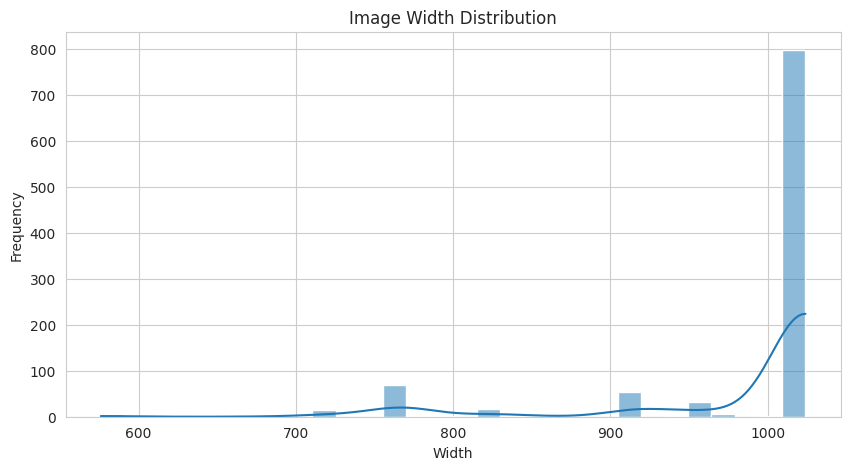

In [54]:
# Image Widht Distribution

plt.figure(figsize=(10,5))

sns.histplot(

    image_widths,

    bins=30,

    kde=True
)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

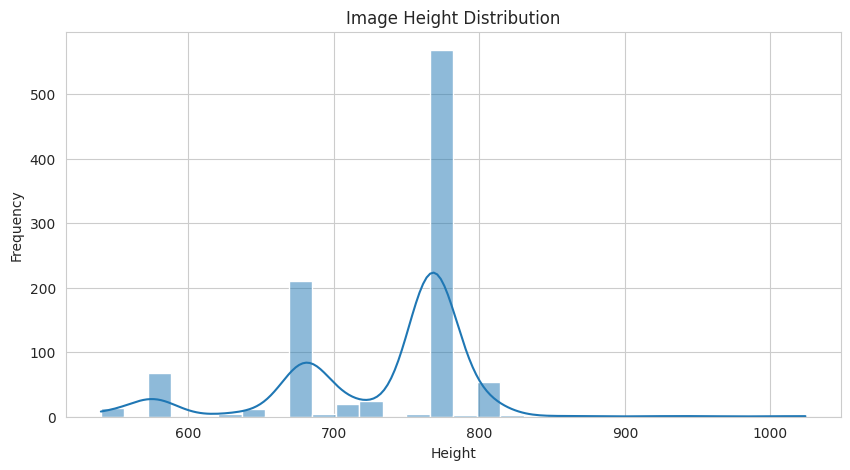

In [55]:
# Image Height Distribution

plt.figure(figsize=(10,5))

sns.histplot(

    image_heights,

    bins=30,

    kde=True
)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

In [56]:
# Unique Image Dimension Analysis

unique_dimensions = len(
    set(zip(image_widths, image_heights))
)

print(
    "Unique Image Dimensions:",
    unique_dimensions
)

Unique Image Dimensions: 84


In [61]:
# Brightness Analysis

brightness_values = []

for path in df_model['image_path'][:500]:

    img = cv2.imread(path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    brightness = np.mean(gray)

    brightness_values.append(brightness)

print(
    "Total analyzed images:",
    len(brightness_values)
)

Total analyzed images: 500


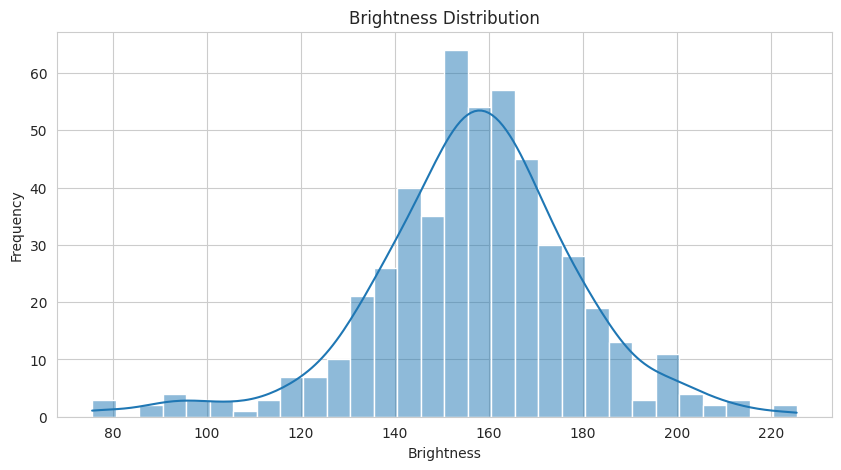

In [62]:
# Brightness Distribution

plt.figure(figsize=(10,5))

sns.histplot(

    brightness_values,

    bins=30,

    kde=True
)

plt.title("Brightness Distribution")

plt.xlabel("Brightness")

plt.ylabel("Frequency")

plt.show()

In [63]:
# Brightness Statistics

brightness_df = pd.DataFrame({

    'Brightness': brightness_values
})

brightness_df.describe()

,Brightness
count,500.000000
mean,156.862683
std,21.966670
min,75.563548
25%,144.995759
50%,157.749474
75%,169.375160
max,225.501960


In [64]:
# RGB Distribution Analysis

red_channel = []

green_channel = []

blue_channel = []

for path in df_model['image_path'][:500]:

    img = cv2.imread(path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    red_channel.append(
        np.mean(img_rgb[:,:,0])
    )

    green_channel.append(
        np.mean(img_rgb[:,:,1])
    )

    blue_channel.append(
        np.mean(img_rgb[:,:,2])
    )

print("Color analysis completed.")

Color analysis completed.


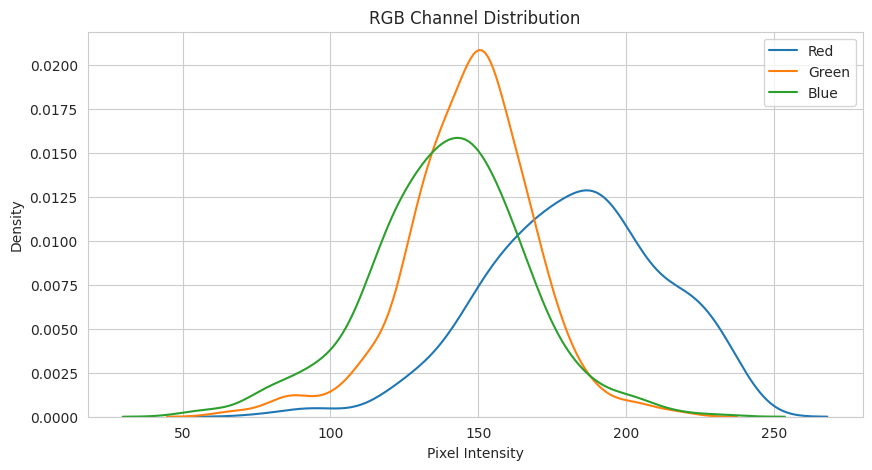

In [65]:
# RGB Channel Distribution

plt.figure(figsize=(10,5))

sns.kdeplot(
    red_channel,
    label='Red'
)

sns.kdeplot(
    green_channel,
    label='Green'
)

sns.kdeplot(
    blue_channel,
    label='Blue'
)

plt.title("RGB Channel Distribution")

plt.xlabel("Pixel Intensity")

plt.ylabel("Density")

plt.legend()

plt.show()

**Insight:**

- Distribusi target class menunjukkan dataset masih mengalami class imbalance dengan dominasi kelas NV dibandingkan kelas MEL dan BCC.

- Analisis usia menunjukkan mayoritas pasien berada pada rentang usia dewasa hingga lansia yang sesuai dengan karakteristik umum kasus penyakit kulit.

- Distribusi usia menunjukkan adanya beberapa nilai ekstrem (outlier) pada kelompok usia tertentu, terutama pada pasien dengan usia lanjut.

- Outlier pada metadata usia masih dianggap valid karena kemungkinan merepresentasikan kondisi pasien nyata pada dataset medis.

- Analisis outlier membantu memahami persebaran data numerik sebelum digunakan pada proses preprocessing dan feature engineering.

- Distribusi jenis kelamin menunjukkan pasien laki-laki memiliki jumlah lebih tinggi dibandingkan perempuan pada dataset.

- Area anatomi paling dominan ditemukan pada torso dan extremity yang menunjukkan lokasi tertentu lebih sering menjadi area munculnya lesi kulit.

- Hasil image dimension analysis menunjukkan mayoritas gambar memiliki ukuran yang relatif konsisten sehingga memudahkan proses preprocessing image.

- Brightness dan RGB distribution analysis menunjukkan variasi pencahayaan dan intensitas warna antar citra namun masih berada pada distribusi yang cukup stabil untuk proses training model AI.

## Bivariate Analysis

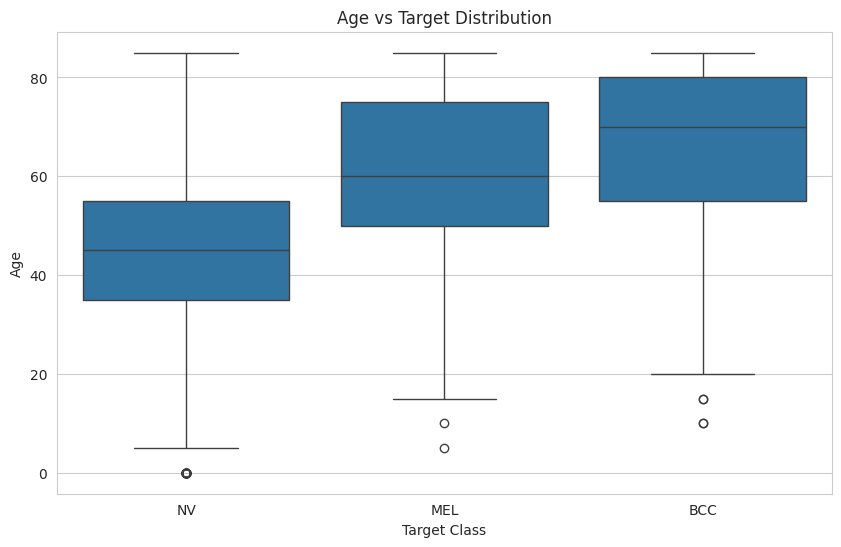

In [66]:
# Age VS Target Distribution

plt.figure(figsize=(10,6))

sns.boxplot(

    data=df_model,

    x='target',

    y='age_approx'
)

plt.title("Age vs Target Distribution")

plt.xlabel("Target Class")

plt.ylabel("Age")

plt.show()

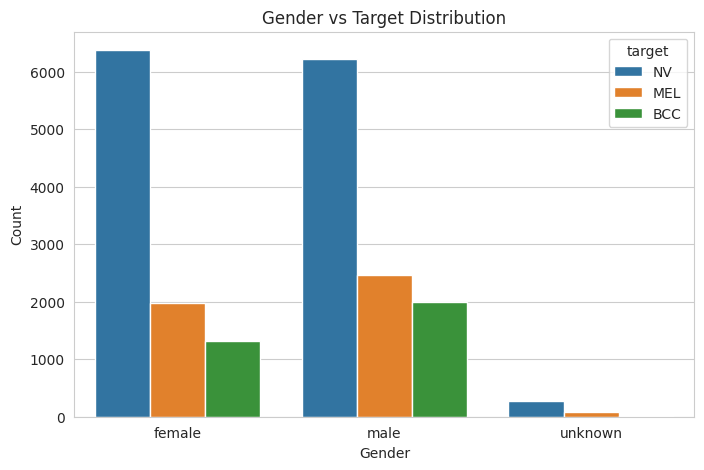

In [67]:
# Gender VS Target Distribution

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_model,

    x='sex',

    hue='target'
)

plt.title("Gender vs Target Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

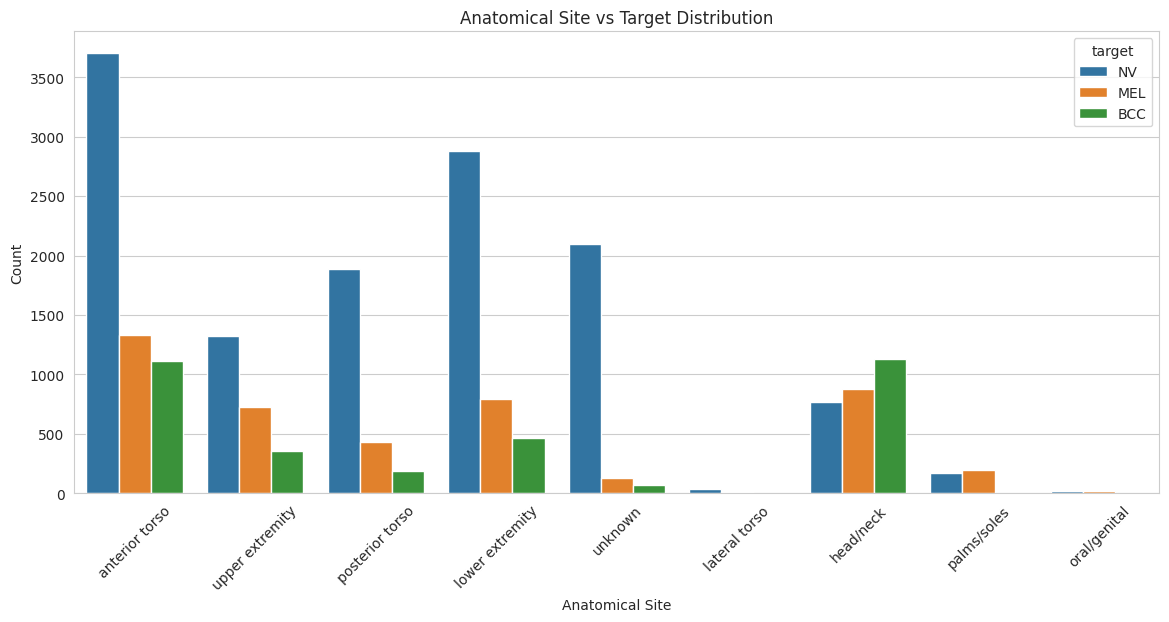

In [68]:
# Anatomical Site VS Target Distribution

plt.figure(figsize=(14,6))

sns.countplot(

    data=df_model,

    x='anatom_site_general',

    hue='target'
)

plt.xticks(rotation=45)

plt.title("Anatomical Site vs Target Distribution")

plt.xlabel("Anatomical Site")

plt.ylabel("Count")

plt.show()

**Insight:**

- Pasien dengan kelas BCC cenderung berada pada kelompok usia lebih tua dibandingkan kelas lainnya, sedangkan NV lebih banyak ditemukan pada usia yang lebih muda.
- Distribusi pasien laki-laki dan perempuan relatif seimbang, namun kelas MEL dan BCC sedikit lebih dominan pada pasien laki-laki.
- Kelas NV paling banyak ditemukan pada area anterior torso, lower extremity, dan posterior torso.
- Kelas BCC lebih dominan pada area head/neck yang cenderung sering terpapar sinar matahari.
- Anatomical site menunjukkan pola distribusi yang berbeda pada setiap kelas penyakit sehingga dapat menjadi karakteristik penting dalam analisis penyakit kulit.

# Preprocessing

In [69]:
# Copy Dataset
df_encoded = df_model.copy()

print("Dataset Shape:")
print(df_encoded.shape)

Dataset Shape:
(20720, 17)


- Label encoding dilakukan untuk mengubah data kategorikal menjadi representasi numerik agar lebih mudah diproses pada tahap analisis dan feature engineering.

- Proses encoding membantu mempermudah eksplorasi hubungan antar fitur menggunakan visualisasi maupun analisis statistik.

In [70]:
# Encode Sex
sex_encoder = LabelEncoder()

df_encoded['sex_encoded'] = sex_encoder.fit_transform(
    df_encoded['sex']
)

print(
    dict(
        zip(
            sex_encoder.classes_,
            sex_encoder.transform(
                sex_encoder.classes_
            )
        )
    )
)

{'female': np.int64(0), 'male': np.int64(1), 'unknown': np.int64(2)}


In [71]:
# Encode Anatomical Site

site_encoder = LabelEncoder()

df_encoded['site_encoded'] = site_encoder.fit_transform(
    df_encoded['anatom_site_general']
)

print(
    dict(
        zip(
            site_encoder.classes_,
            site_encoder.transform(
                site_encoder.classes_
            )
        )
    )
)

{'anterior torso': np.int64(0), 'head/neck': np.int64(1), 'lateral torso': np.int64(2), 'lower extremity': np.int64(3), 'oral/genital': np.int64(4), 'palms/soles': np.int64(5), 'posterior torso': np.int64(6), 'unknown': np.int64(7), 'upper extremity': np.int64(8)}


In [72]:
# Encode Target

target_encoder = LabelEncoder()

df_encoded['target_encoded'] = target_encoder.fit_transform(
    df_encoded['target']
)

print(
    dict(
        zip(
            target_encoder.classes_,
            target_encoder.transform(
                target_encoder.classes_
            )
        )
    )
)

{'BCC': np.int64(0), 'MEL': np.int64(1), 'NV': np.int64(2)}


In [73]:
# Check Encoding Result

df_encoded[[
    'sex',
    'sex_encoded',
    'anatom_site_general',
    'site_encoded',
    'target',
    'target_encoded'
]].head()

,sex,sex_encoded,anatom_site_general,site_encoded,target,target_encoded
0,female,0,anterior torso,0,NV,2
1,female,0,anterior torso,0,NV,2
2,female,0,upper extremity,8,MEL,1
3,male,1,upper extremity,8,NV,2
4,male,1,posterior torso,6,MEL,1


**Insight:**

- Proses categorical encoding dilakukan untuk mengubah fitur kategorikal menjadi representasi numerik agar dapat diproses oleh model machine learning dan deep learning.

- Fitur `sex`, `anatom_site_general`, dan `target` berhasil dikonversi menggunakan Label Encoding tanpa kehilangan informasi kategorikal utama.

- Dataset preprocessing difokuskan pada tiga kelas utama yaitu MEL, NV, dan BCC

In [74]:
# Image Preprocessing Preview
# Sample Image Loading

sample_path = df_model.iloc[0]['image_path']

img = cv2.imread(sample_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

print(
    "Original Image Shape:",
    img_rgb.shape
)

Original Image Shape: (767, 1022, 3)


- Tahapan image preprocessing dilakukan untuk mempersiapkan citra medis sebelum digunakan pada proses modeling deep learning.

- Resize citra membantu menghasilkan ukuran gambar yang konsisten, sedangkan normalisasi piksel membantu meningkatkan stabilitas proses training model AI.

In [75]:
# Image Resize Preview

IMG_SIZE = 224

resized_img = cv2.resize(

    img_rgb,

    (IMG_SIZE, IMG_SIZE)
)

print(
    "Resized Image Shape:",
    resized_img.shape
)

Resized Image Shape: (224, 224, 3)


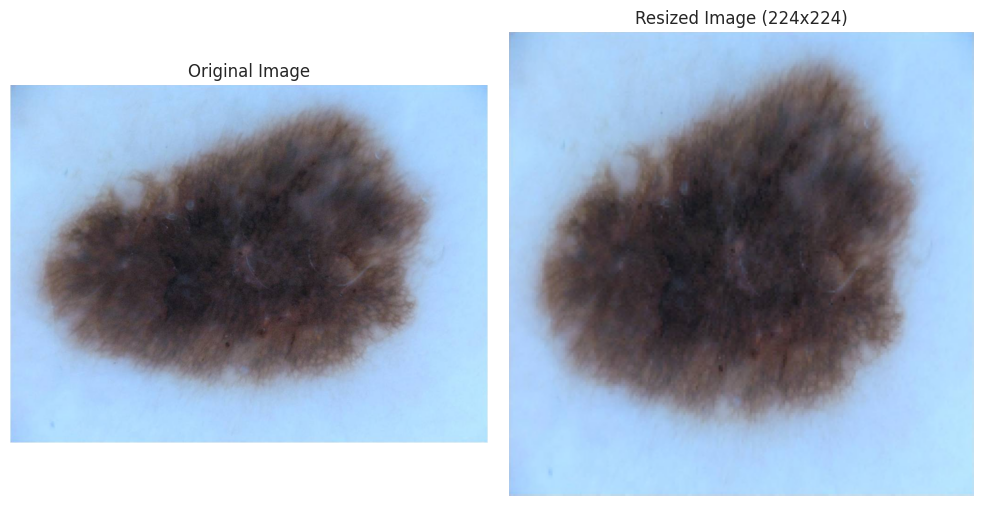

In [76]:
# Original VS Resized Image

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(img_rgb)

plt.title("Original Image")

plt.axis('off')

plt.subplot(1,2,2)

plt.imshow(resized_img)

plt.title(f"Resized Image ({IMG_SIZE}x{IMG_SIZE})")

plt.axis('off')

plt.tight_layout()

plt.show()

In [77]:
# Image Normalization Preview

normalized_img = resized_img / 255.0

print(
    "Minimum Pixel Value:",
    normalized_img.min()
)

print(
    "Maximum Pixel Value:",
    normalized_img.max()
)

Minimum Pixel Value: 0.06666666666666667
Maximum Pixel Value: 1.0


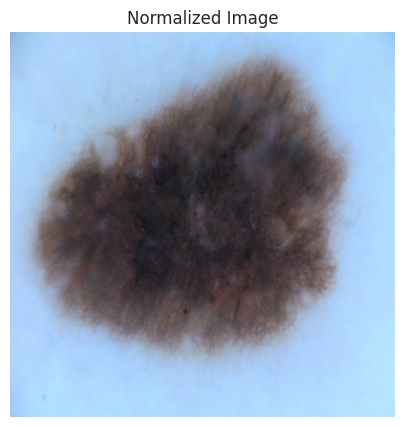

In [78]:
# Normalized Image Visualization

plt.figure(figsize=(5,5))

plt.imshow(normalized_img)

plt.title("Normalized Image")

plt.axis('off')

plt.show()

**Insight:**

- Analisis dimensi citra menunjukkan dataset memiliki variasi ukuran gambar yang cukup beragam sehingga diperlukan proses resize untuk menghasilkan ukuran input yang konsisten sebelum proses modeling dilakukan.

- Resize citra ke ukuran 224x224 dilakukan untuk menyesuaikan kebutuhan arsitektur convolutional neural network (CNN) yang umum digunakan pada klasifikasi citra medis.

- Normalisasi piksel membantu mengubah rentang nilai citra menjadi 0–1 sehingga proses training model menjadi lebih stabil dan efisien.

- Tahapan image preprocessing membantu mempersiapkan dataset citra medis yang lebih optimal dan terstandarisasi untuk proses pengembangan model klasifikasi kanker kulit berbasis AI.

# Feature Engineering

- Feature engineering dilakukan untuk menghasilkan fitur tambahan yang lebih informatif berdasarkan metadata pasien.

- Pembentukan fitur `age_group` membantu menyederhanakan distribusi usia ke dalam kelompok umur tertentu sehingga pola distribusi penyakit lebih mudah dianalisis.

- Fitur `risk_category` digunakan untuk mengelompokkan tingkat risiko penyakit kulit berdasarkan tingkat keganasan kanker kulit.

In [79]:
# Age Group Feature Engineering

def categorize_age(age):

    if age < 18:
        return 'child'

    elif age < 40:
        return 'young_adult'

    elif age < 60:
        return 'adult'

    else:
        return 'senior'


df_encoded['age_group'] = df_encoded['age_approx'].apply(
    categorize_age
)

df_encoded['age_group'].value_counts()

,count
age_group,
adult,8772
senior,7580
young_adult,3714
child,654


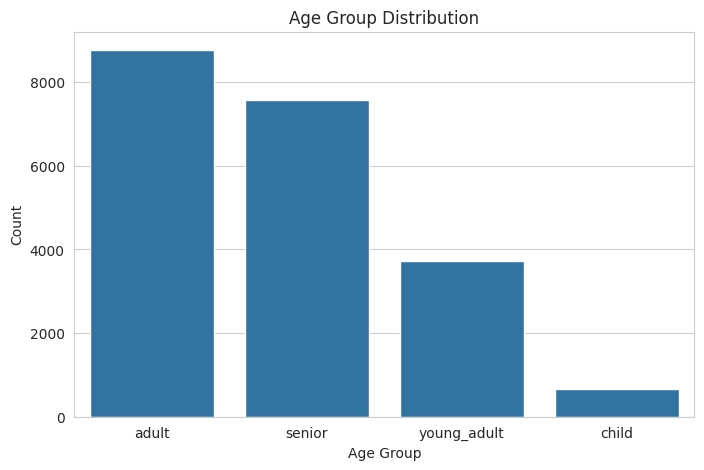

In [80]:
# Visualisasi Age Group Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_encoded,
    x='age_group',
    order=df_encoded['age_group'].value_counts().index
)

plt.title("Age Group Distribution")

plt.xlabel("Age Group")

plt.ylabel("Count")

plt.show()

In [81]:
# Encode Age Group

age_group_encoder = LabelEncoder()

df_encoded['age_group_encoded'] = (
    age_group_encoder.fit_transform(
        df_encoded['age_group']
    )
)

print(
    dict(
        zip(
            age_group_encoder.classes_,
            age_group_encoder.transform(
                age_group_encoder.classes_
            )
        )
    )
)

{'adult': np.int64(0), 'child': np.int64(1), 'senior': np.int64(2), 'young_adult': np.int64(3)}


In [82]:
# Medical Risk Feature Engineering

# High-risk classes based on medical severity

high_risk_classes = [

    'MEL',
    'BCC'
]

df_encoded['risk_category'] = df_encoded['target'].apply(

    lambda x:

    'high_risk'

    if x in high_risk_classes

    else 'low_risk'
)

df_encoded['risk_category'].value_counts()

,count
risk_category,
low_risk,12875
high_risk,7845


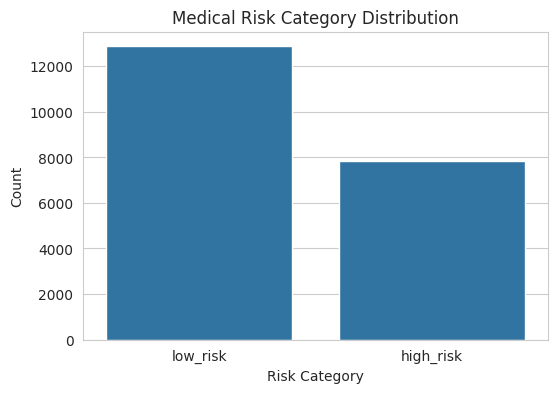

In [83]:
# Visualization Risk Categry

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_encoded,
    x='risk_category'
)

plt.title("Medical Risk Category Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.show()

In [84]:
# Encode Risk Category

risk_encoder = LabelEncoder()

df_encoded['risk_encoded'] = (

    risk_encoder.fit_transform(
        df_encoded['risk_category']
    )
)

print(
    dict(
        zip(
            risk_encoder.classes_,
            risk_encoder.transform(
                risk_encoder.classes_
            )
        )
    )
)

{'high_risk': np.int64(0), 'low_risk': np.int64(1)}


Feature `site_risk_score` dibentuk berdasarkan lokasi anatomi lesi untuk merepresentasikan tingkat risiko relatif pada setiap area tubuh. Pendekatan ini digunakan untuk mengubah informasi kategorikal lokasi lesi menjadi nilai numerik yang lebih mudah dianalisis dan dapat dimanfaatkan pada proses modeling AI.

In [89]:
# Site Risk Score Feature Engineering

SITE_RISK_SCORE = {

    "head/neck": 0.8,

    "torso": 0.7,

    "anterior torso": 0.7,

    "posterior torso": 0.7,

    "lateral torso": 0.6,

    "upper extremity": 0.5,

    "lower extremity": 0.5,

    "palms/soles": 0.9,

    "oral/genital": 0.85,

    "unknown": 0.6
}

df_encoded["site_risk_score"] = (

    df_encoded["anatom_site_general"]

    .map(SITE_RISK_SCORE)
)

df_encoded[
    [
        "anatom_site_general",
        "site_risk_score"
    ]
].head()

,anatom_site_general,site_risk_score
0,anterior torso,0.7
1,anterior torso,0.7
2,upper extremity,0.5
3,upper extremity,0.5
4,posterior torso,0.7


In [90]:
df_encoded["site_risk_score"].isnull().sum()

np.int64(0)

In [85]:
# PATIENT LEAKAGE ANALYSIS
# Lesion Duplicate Analysis

lesion_counts = (

    df_encoded['lesion_id']
    .value_counts()
)

duplicated_lesions = lesion_counts[
    lesion_counts > 1
]

print(
    "Total duplicated lesion_id:",
    len(duplicated_lesions)
)

Total duplicated lesion_id: 3954


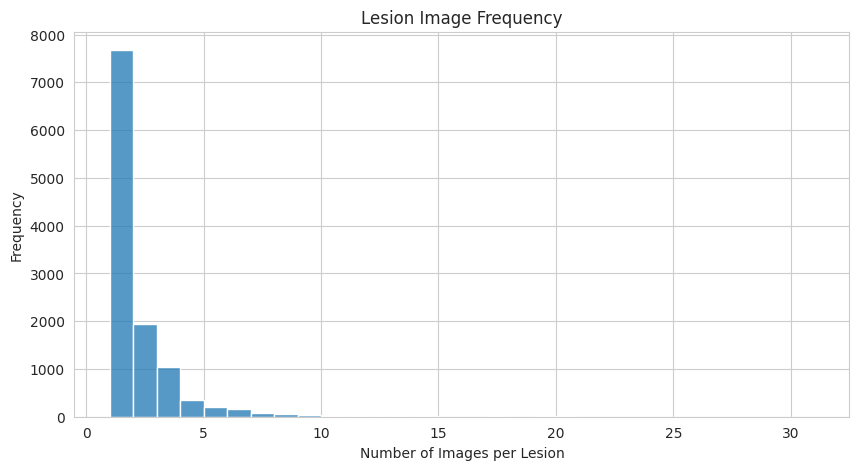

In [86]:
# Visualization Lesion Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    lesion_counts,
    bins=30
)

plt.title("Lesion Image Frequency")

plt.xlabel("Number of Images per Lesion")

plt.ylabel("Frequency")

plt.show()

In [87]:
# Max Image Per Lesion

print(
    "Maximum images per lesion:",
    lesion_counts.max()
)

Maximum images per lesion: 31


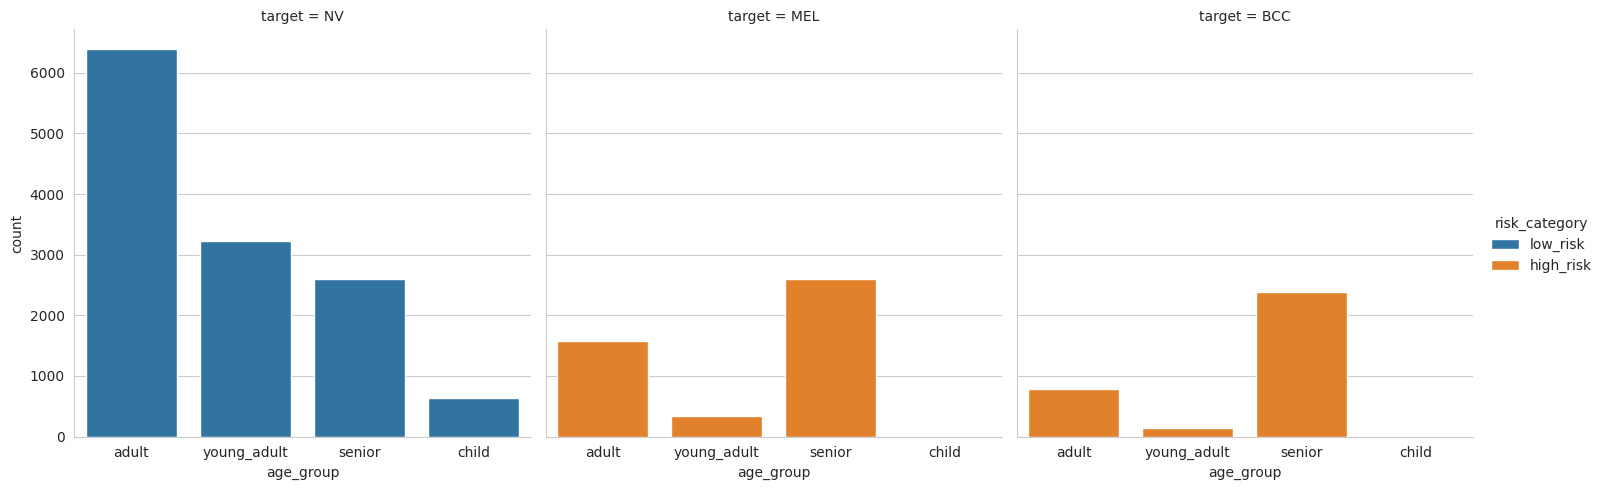

In [88]:
# Feature Relationship Analysis
sns.catplot(
    data=df_encoded,
    x='age_group',
    hue='risk_category',
    col='target',
    kind='count'
)

**Insight:**

- Feature engineering menghasilkan fitur baru berupa `age_group`, `risk_category`, dan `site_risk_score` untuk memperkaya representasi metadata pasien sebelum digunakan pada proses analisis dan pengembangan model AI.

- Fitur `age_group` membantu menyederhanakan informasi usia pasien ke dalam kelompok umur yang lebih mudah diinterpretasikan pada analisis distribusi penyakit kulit. Fitur ini terutama digunakan untuk kebutuhan eksplorasi data dan explanatory analysis.

- Fitur `risk_category` mengelompokkan Melanoma (MEL) dan Basal Cell Carcinoma (BCC) ke dalam kategori `high_risk`, sedangkan Melanocytic Nevi (NV) dikategorikan sebagai `low_risk` berdasarkan tingkat risiko keganasan relatif masing-masing penyakit. Fitur ini digunakan untuk membantu interpretasi karakteristik klinis pada dataset.

- Fitur `site_risk_score` mengubah informasi lokasi anatomi lesi menjadi representasi numerik yang mencerminkan tingkat risiko relatif pada setiap area tubuh. Berbeda dengan `age_group` dan `risk_category` yang lebih berfokus pada analisis eksploratif, fitur `site_risk_score` dipersiapkan sebagai salah satu metadata numerik yang dapat dimanfaatkan pada proses modeling AI dan perhitungan severity scoring pada tahap pengembangan sistem.

- Analisis lesion duplication menunjukkan bahwa beberapa `lesion_id` memiliki lebih dari satu citra. Kondisi ini umum ditemukan pada medical imaging dataset karena satu lesi dapat didokumentasikan dari berbagai sudut pengambilan gambar atau kondisi pencahayaan yang berbeda.

- Informasi duplicate lesion menjadi dasar penerapan leakage-aware data splitting pada tahap data preparation untuk mengurangi risiko kebocoran informasi antar subset train, validation, dan test.

# Visualization & Explanatory Analysis

## Pertanyaan 1
Bagaimana karakteristik distribusi Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) berdasarkan metadata pasien seperti usia, jenis kelamin, dan lokasi anatomi lesi?

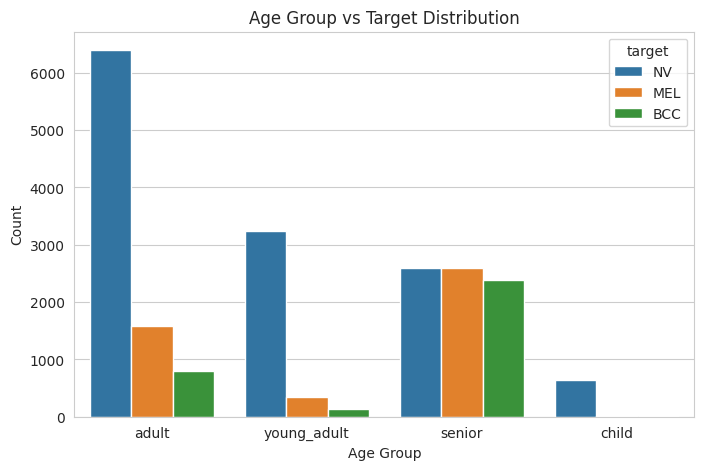

In [91]:
# Age Group Distribution

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_encoded,

    x='age_group',

    hue='target'
)

plt.title("Age Group vs Target Distribution")

plt.xlabel("Age Group")

plt.ylabel("Count")

plt.show()

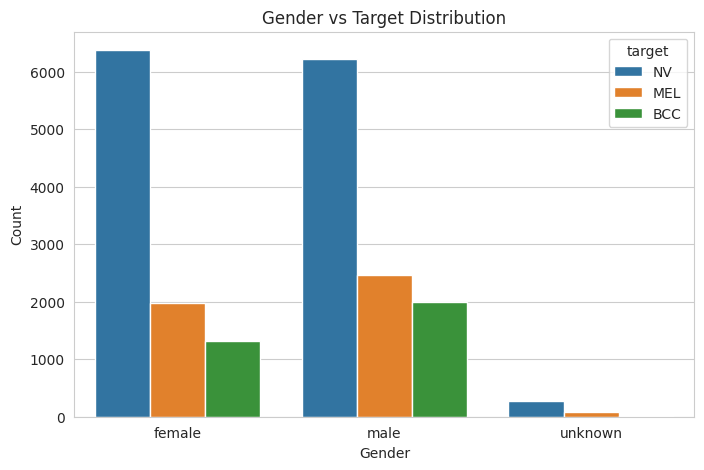

In [92]:
# Gender VS Target Distribution

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_encoded,

    x='sex',

    hue='target'
)

plt.title("Gender vs Target Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

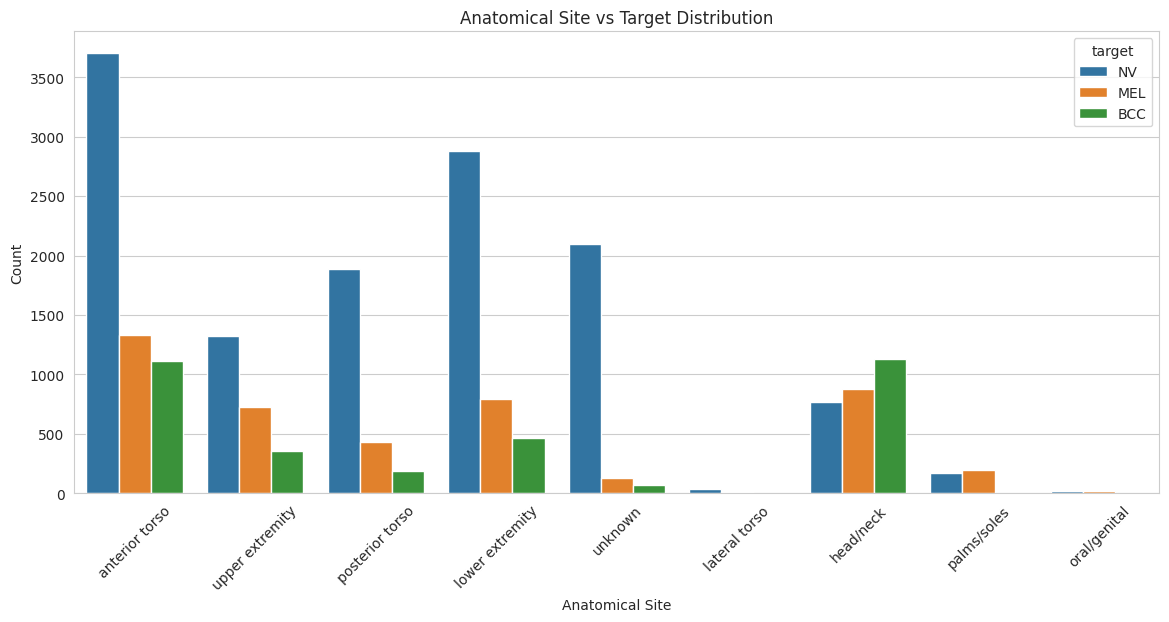

In [93]:
# Anatomical Site VS Target Distribusi

plt.figure(figsize=(14,6))

sns.countplot(

    data=df_encoded,

    x='anatom_site_general',

    hue='target'
)

plt.xticks(rotation=45)

plt.title("Anatomical Site vs Target Distribution")

plt.xlabel("Anatomical Site")

plt.ylabel("Count")

plt.show()

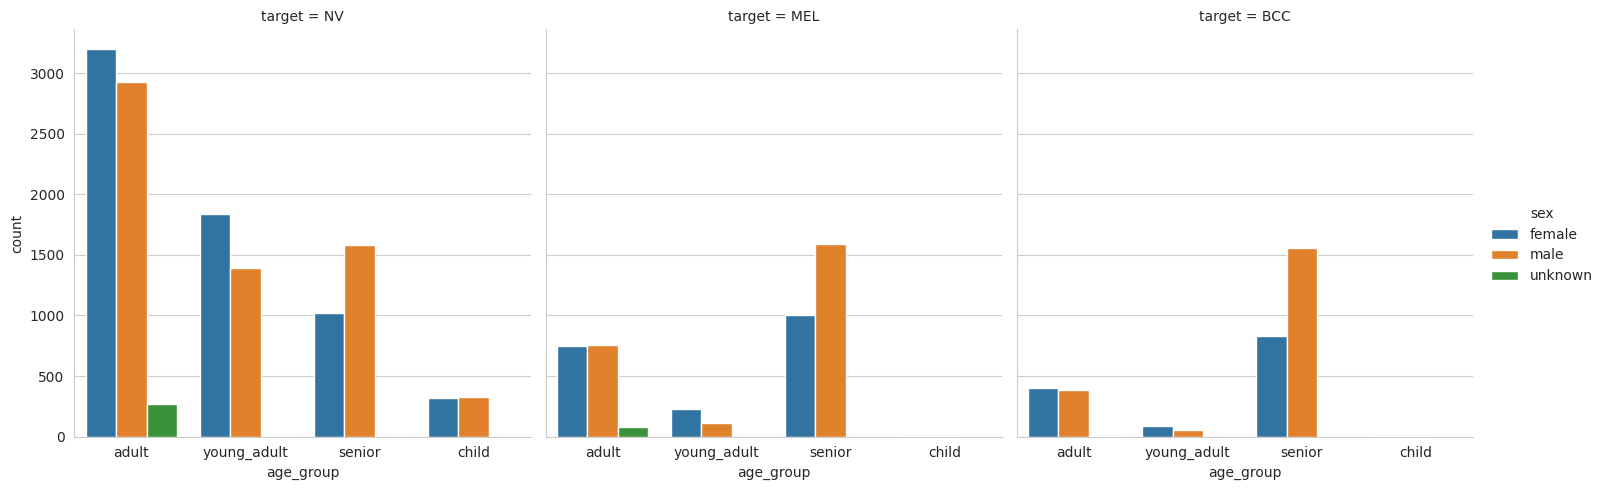

In [94]:
# Multivariate Relationship Analysis

sns.catplot(

    data=df_encoded,

    x='age_group',

    hue='sex',

    col='target',

    kind='count',

    height=5,

    aspect=1
)

plt.show()

**Insight:**

- Distribusi penyakit kulit menunjukkan bahwa kelas Melanocytic Nevi (NV) mendominasi dataset pada hampir seluruh kelompok usia dibandingkan Melanoma (MEL) dan Basal Cell Carcinoma (BCC).

- Berdasarkan distribusi usia, kasus Melanoma (MEL) dan Basal Cell Carcinoma (BCC) lebih banyak ditemukan pada kelompok usia dewasa hingga lansia, sedangkan kelompok usia anak memiliki jumlah kasus yang sangat rendah.

- Distribusi jenis kelamin menunjukkan pasien laki-laki memiliki jumlah kasus lebih tinggi dibandingkan perempuan pada sebagian besar kelas penyakit kulit, terutama pada Melanoma (MEL) dan Basal Cell Carcinoma (BCC).

- Berdasarkan lokasi anatomi lesi, area anterior torso, lower extremity, dan posterior torso menjadi lokasi paling umum munculnya lesi kulit pada dataset. Sementara itu, kelas Basal Cell Carcinoma (BCC) lebih dominan ditemukan pada area head/neck dibandingkan kelas lainnya.

- Analisis multivariat menunjukkan adanya keterkaitan antara faktor usia, jenis kelamin, dan lokasi anatomi terhadap distribusi jenis penyakit kulit sehingga metadata pasien dapat menjadi informasi pendukung yang penting dalam eksplorasi karakteristik kanker kulit berbasis AI.


## Pertanyaan 2
Apakah terdapat ketidakseimbangan distribusi kelas (class imbalance) pada dataset Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) yang dapat mempengaruhi performa model klasifikasi AI?

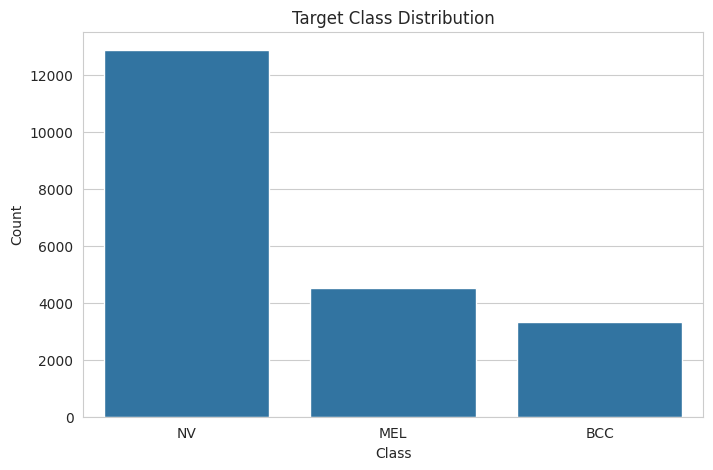

In [95]:
# Target Class Distribution

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_model,

    x='target',

    order=df_model[
        'target'
    ].value_counts().index
)

plt.title("Target Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

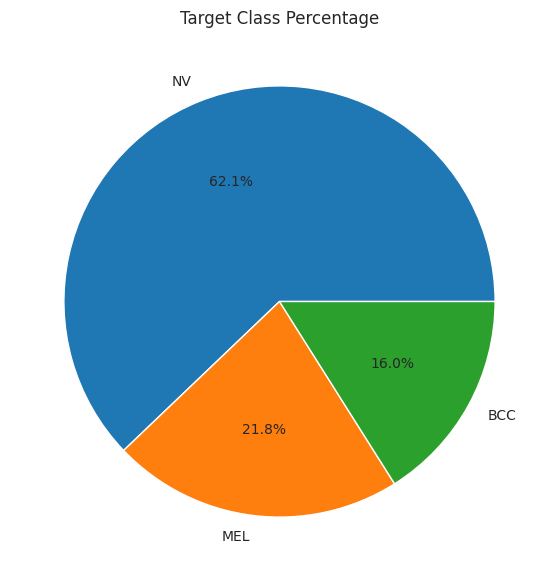

In [96]:
# Target Class Percentage

df_model['target'].value_counts().plot(

    kind='pie',

    autopct='%1.1f%%',

    figsize=(7,7)
)

plt.ylabel("")

plt.title("Target Class Percentage")

plt.show()

In [97]:
# Class Imbalance Ratio

class_counts = (
    df_model['target']
    .value_counts()
)

imbalance_ratio = round(

    class_counts.max() /

    class_counts.min(),

    2
)

print(
    "Imbalance Ratio:",
    imbalance_ratio
)

Imbalance Ratio: 3.87


**Insight:**

- Distribusi kelas pada dataset menunjukkan kondisi class imbalance dengan dominasi kelas Melanocytic Nevi (NV) sebesar 62.1% dibandingkan Melanoma (MEL) sebesar 21.8% dan Basal Cell Carcinoma (BCC) sebesar 16.0%.

- Perbandingan jumlah data antar kelas menghasilkan imbalance ratio sebesar 3.87 yang menunjukkan bahwa jumlah data pada kelas mayoritas hampir empat kali lebih besar dibandingkan kelas minoritas.

- Kondisi class imbalance berpotensi menyebabkan model AI lebih bias terhadap kelas mayoritas sehingga performa klasifikasi pada kelas minoritas seperti Melanoma (MEL) dan Basal Cell Carcinoma (BCC) dapat menurun.

- Ketidakseimbangan distribusi kelas menjadi salah satu alasan dilakukannya proses **undersampling** pada tahap **data preparation** untuk menghasilkan distribusi dataset yang lebih seimbang sebelum proses modeling AI dilakukan.

## Pertanyaan 3
Bagaimana kualitas dan karakteristik citra medis pada dataset Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC) yang akan digunakan untuk pengembangan model klasifikasi kanker kulit berbasis AI?

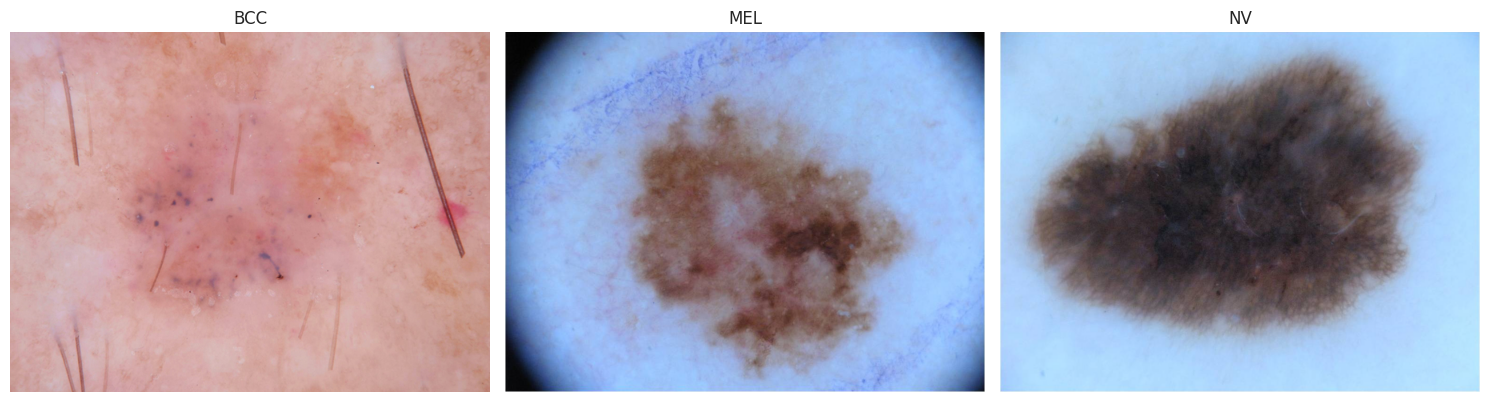

In [98]:
# Sample Image Visualization

sample_per_class = (

    df_model

    .groupby('target')

    .first()

    .reset_index()
)

plt.figure(figsize=(15,5))

for i, row in enumerate(
    sample_per_class.itertuples()
):

    img = Image.open(row.image_path)

    plt.subplot(1,3,i+1)

    plt.imshow(img)

    plt.title(row.target)

    plt.axis('off')

plt.tight_layout()

plt.show()

In [99]:
# Image Dimension Analysis

image_widths = []

image_heights = []

for path in df_model['image_path'][:500]:

    img = Image.open(path)

    width, height = img.size

    image_widths.append(width)

    image_heights.append(height)

print(
    "Unique Dimensions:",
    len(set(zip(image_widths, image_heights)))
)

Unique Dimensions: 84


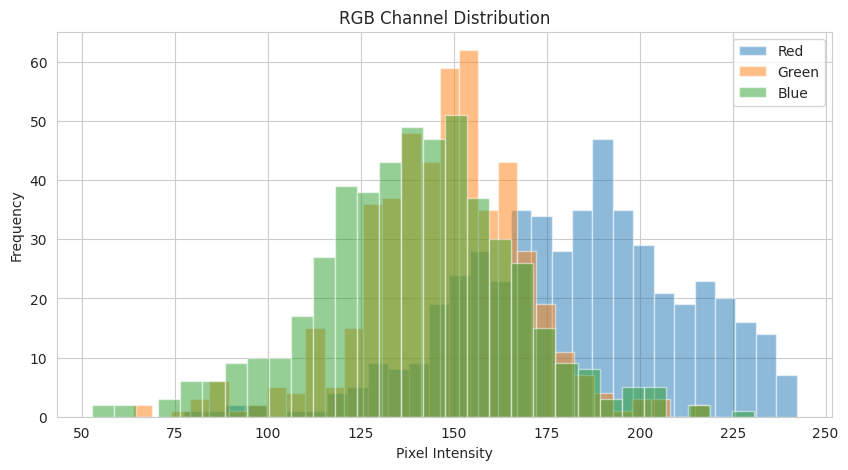

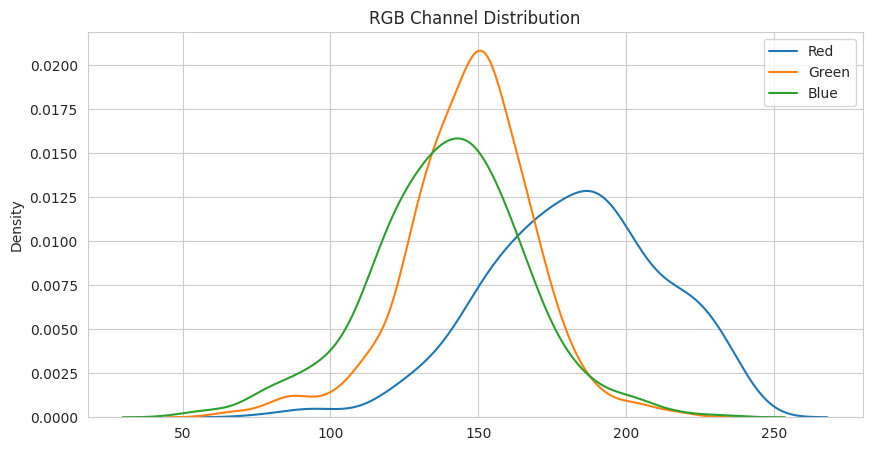

In [100]:
# RGB Distribution

plt.figure(figsize=(10,5))

plt.hist(

    red_channel,

    bins=30,

    alpha=0.5,

    label='Red'
)

plt.hist(

    green_channel,

    bins=30,

    alpha=0.5,

    label='Green'
)

plt.hist(

    blue_channel,

    bins=30,

    alpha=0.5,

    label='Blue'
)

plt.title("RGB Channel Distribution")

plt.xlabel("Pixel Intensity")

plt.ylabel("Frequency")

plt.legend()

plt.show()


red_channel = []

green_channel = []

blue_channel = []

for path in df_model['image_path'][:500]:

    img = cv2.imread(path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    red_channel.append(
        np.mean(img_rgb[:,:,0])
    )

    green_channel.append(
        np.mean(img_rgb[:,:,1])
    )

    blue_channel.append(
        np.mean(img_rgb[:,:,2])
    )

plt.figure(figsize=(10,5))

sns.kdeplot(red_channel, label='Red')
sns.kdeplot(green_channel, label='Green')
sns.kdeplot(blue_channel, label='Blue')

plt.title("RGB Channel Distribution")

plt.legend()

plt.show()


**Insight:**

- Visualisasi sample image menunjukkan adanya perbedaan karakteristik visual antar kelas penyakit kulit. Lesi Melanoma (MEL) cenderung memiliki pola warna dan bentuk yang lebih tidak beraturan, sedangkan Melanocytic Nevi (NV) memiliki warna pigmen yang lebih gelap dan merata. Basal Cell Carcinoma (BCC) menunjukkan karakteristik lesi dengan warna yang lebih terang dan tekstur yang berbeda dibandingkan kelas lainnya.

- Analisis dimensi citra menunjukkan terdapat 84 variasi ukuran gambar pada dataset sehingga diperlukan proses resize agar seluruh citra memiliki ukuran yang konsisten sebelum digunakan pada proses modeling AI.

- Distribusi RGB channel menunjukkan channel merah memiliki intensitas lebih tinggi dibandingkan channel hijau dan biru. Kondisi ini menunjukkan dominasi warna merah atau coklat pada citra lesi kulit yang merupakan karakteristik umum pada citra dermatoskopi medis.

- Distribusi brightness dan RGB menunjukkan variasi pencahayaan antar citra, namun mayoritas citra masih berada pada rentang intensitas yang relatif stabil sehingga dataset tetap layak digunakan untuk pengembangan model klasifikasi kanker kulit berbasis AI.

- Analisis kualitas citra membantu memastikan dataset memiliki karakteristik visual yang cukup representatif untuk proses pembelajaran pola lesi kulit pada model deep learning.

## Pertanyaan 4
Bagaimana proses preprocessing dan feature engineering membantu meningkatkan kualitas dataset serta mendukung analisis karakteristik Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC)?

In [ ]:
# Encoding Result

df_encoded[[

    'sex',

    'sex_encoded',

    'anatom_site_general',

    'site_encoded',

    'target',

    'target_encoded'

]].head()

,sex,sex_encoded,anatom_site_general,site_encoded,target,target_encoded
0,female,0,anterior torso,0,NV,2
1,female,0,anterior torso,0,NV,2
2,female,0,upper extremity,8,MEL,1
3,male,1,upper extremity,8,NV,2
4,male,1,posterior torso,6,MEL,1


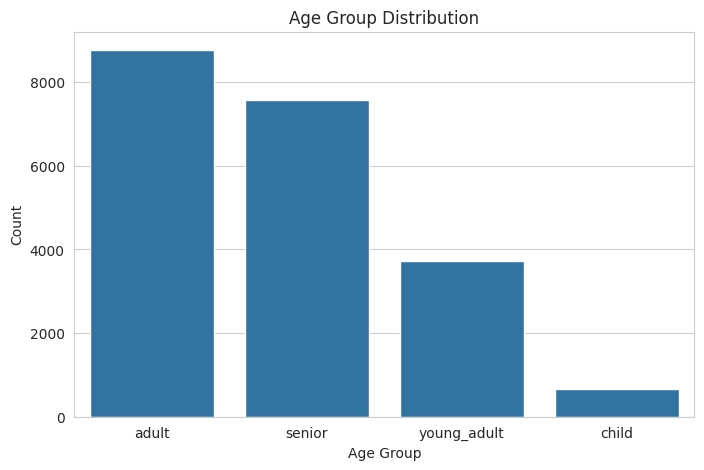

In [ ]:
# Age Group Distribution

plt.figure(figsize=(8,5))

sns.countplot(

    data=df_encoded,

    x='age_group',

    order=df_encoded[
        'age_group'
    ].value_counts().index
)

plt.title("Age Group Distribution")

plt.xlabel("Age Group")

plt.ylabel("Count")

plt.show()

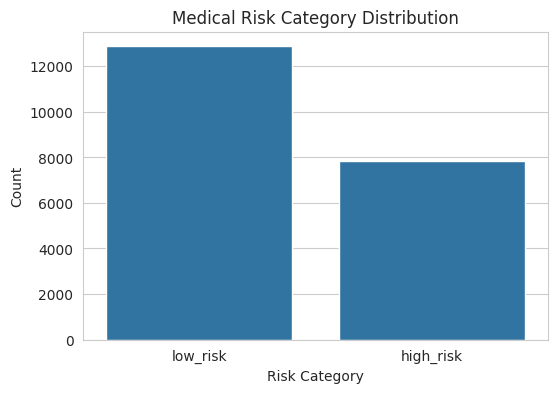

In [ ]:
# Risk Category Distribution

plt.figure(figsize=(6,4))

sns.countplot(

    data=df_encoded,

    x='risk_category'
)

plt.title("Medical Risk Category Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.show()

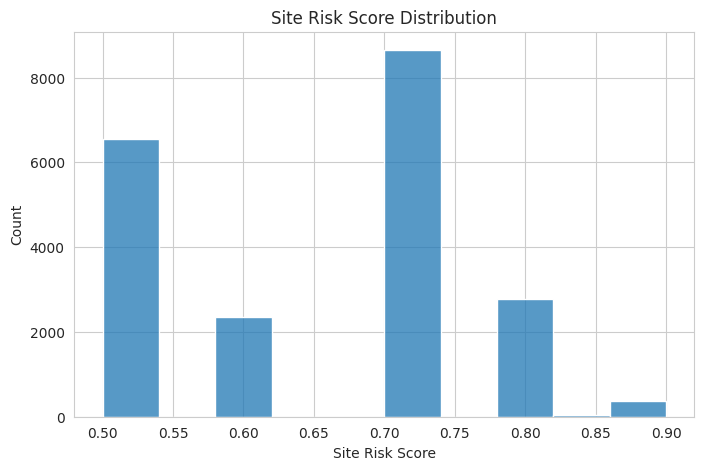

In [101]:
# Site Risk Score Distribution

plt.figure(figsize=(8,5))

sns.histplot(

    data=df_encoded,

    x='site_risk_score',

    bins=10
)

plt.title("Site Risk Score Distribution")

plt.xlabel("Site Risk Score")

plt.ylabel("Count")

plt.show()

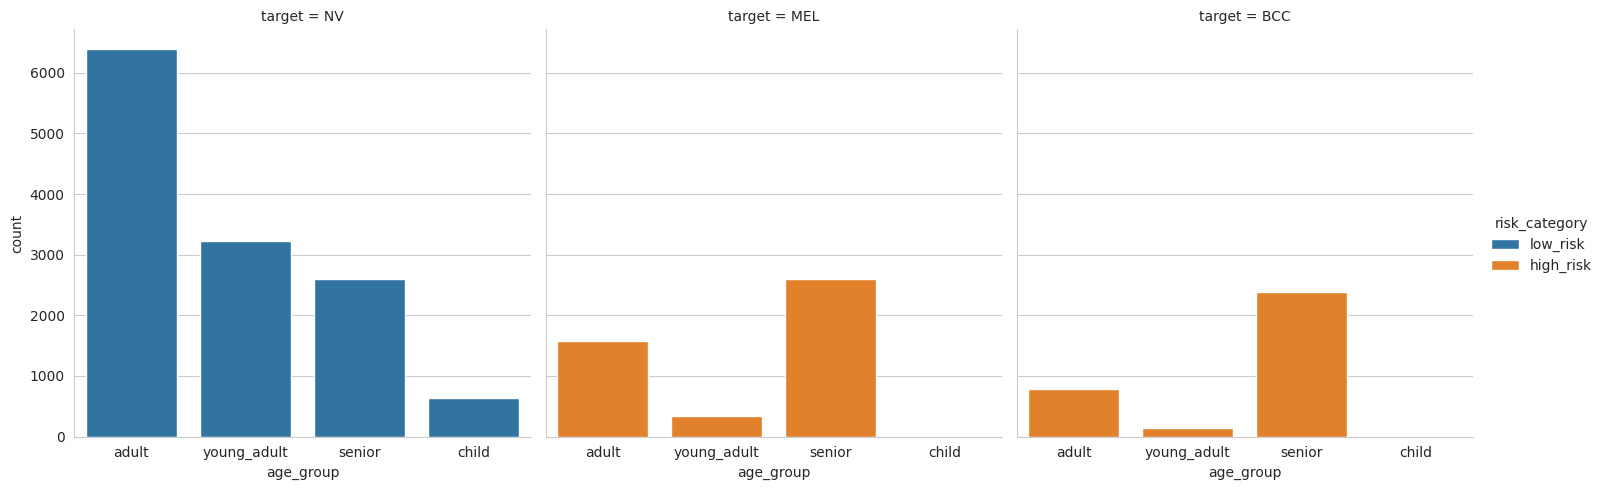

In [ ]:
# Feature Relationship Analysis

sns.catplot(

    data=df_encoded,

    x='age_group',

    hue='risk_category',

    col='target',

    kind='count',

    height=5,

    aspect=1
)

plt.show()

Age Group Category

| Age Group     | Age Range |
|----------------|------------|
| child          | < 18 tahun |
| young_adult    | 18 – 39 tahun |
| adult          | 40 – 59 tahun |
| senior         | ≥ 60 tahun |

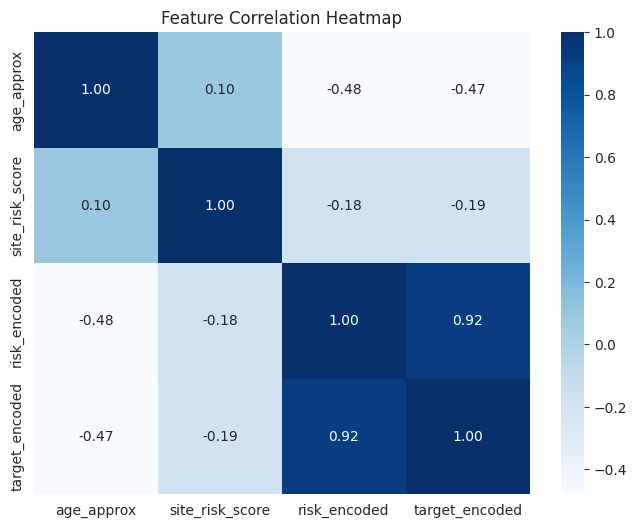

In [102]:
# Correlation Heatmap Analysis

heatmap_df = df_encoded[[

    'age_approx',

    'site_risk_score',

    'risk_encoded',

    'target_encoded'
]]

plt.figure(figsize=(8,6))

sns.heatmap(

    heatmap_df.corr(),

    annot=True,

    cmap='Blues',

    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

**Note**

Fitur `site_risk_score` dipersiapkan sebagai metadata numerik yang dapat dimanfaatkan pada proses modeling AI. Berbeda dengan `age_group` dan `risk_category` yang lebih berfokus pada kebutuhan analisis eksploratif dan interpretasi data, `site_risk_score` digunakan untuk merepresentasikan tingkat risiko relatif lokasi anatomi lesi dalam bentuk numerik yang lebih mudah diintegrasikan ke dalam proses perhitungan dan pengembangan sistem AI.

**Insight:**

- Proses preprocessing berhasil menangani missing value serta mengubah data kategorikal seperti jenis kelamin, lokasi anatomi lesi, dan target kelas menjadi representasi numerik yang lebih terstruktur melalui proses encoding.

- Feature engineering menghasilkan fitur baru berupa `age_group`, `risk_category`, dan `site_risk_score` untuk memperkaya representasi metadata pasien pada proses analisis maupun pengembangan model AI.

- Distribusi `age_group` menunjukkan bahwa mayoritas pasien berada pada kelompok usia dewasa (40–59 tahun) dan lansia (≥60 tahun), sedangkan kelompok usia anak (<18 tahun) memiliki jumlah kasus yang sangat rendah pada dataset.

- Distribusi `risk_category` menunjukkan kategori `low_risk` lebih dominan dibandingkan `high_risk` karena kelas Melanocytic Nevi (NV) memiliki jumlah data terbesar pada dataset.

- Distribusi `site_risk_score` menunjukkan bahwa sebagian besar lesi berada pada lokasi dengan tingkat risiko menengah (0.5–0.7), seperti area torso dan ekstremitas, sedangkan lokasi dengan skor risiko tinggi seperti head/neck, oral/genital, dan palms/soles memiliki jumlah data yang relatif lebih sedikit.

- Analisis hubungan fitur menunjukkan bahwa kategori `high_risk` lebih banyak ditemukan pada kelompok usia dewasa hingga lansia, terutama pada kelas Melanoma (MEL) dan Basal Cell Carcinoma (BCC), sedangkan kelas Melanocytic Nevi (NV) mendominasi kategori `low_risk`.

- Correlation heatmap menunjukkan korelasi yang sangat kuat antara `risk_encoded` dan `target_encoded` (0.92) karena fitur `risk_category` dibentuk langsung berdasarkan kelas target. Sementara itu, fitur `age_approx` dan `site_risk_score` memiliki korelasi rendah hingga sedang yang menunjukkan bahwa kedua fitur tersebut memberikan informasi tambahan yang relatif independen terhadap target.

- Secara keseluruhan, tahapan preprocessing dan feature engineering berhasil menghasilkan dataset yang lebih bersih, terstruktur, dan informatif sehingga mendukung proses analisis karakteristik penyakit kulit serta mempersiapkan metadata yang lebih optimal untuk kebutuhan modeling AI.

# Data Preparation

## Split Dataset

In [103]:
# Copy Final Dataset

final_df = df_encoded.copy()

print("Final Dataset Shape:")
print(final_df.shape)

Final Dataset Shape:
(20720, 25)


In [104]:
# Split Dataset
# Lesion-level Split

unique_lesions = final_df['lesion_id'].unique()

train_lesions, temp_lesions = train_test_split(

    unique_lesions,

    test_size=0.2,

    random_state=42
)

val_lesions, test_lesions = train_test_split(

    temp_lesions,

    test_size=0.5,

    random_state=42
)

# Create Split DataFrame

train_df = final_df[
    final_df['lesion_id'].isin(train_lesions)
].copy()

val_df = final_df[
    final_df['lesion_id'].isin(val_lesions)
].copy()

test_df = final_df[
    final_df['lesion_id'].isin(test_lesions)
].copy()

In [105]:
# Check Split Shape

print("Before Undersampling")

print("Train Shape :", train_df.shape)

print("Validation Shape :", val_df.shape)

print("Test Shape :", test_df.shape)

Before Undersampling
Train Shape : (16600, 25)
Validation Shape : (2021, 25)
Test Shape : (2099, 25)


In [106]:
# Check Distribution Class

print("Train Distribution")
print(train_df['target'].value_counts())

print("\nValidation Distribution")
print(val_df['target'].value_counts())

print("\nTest Distribution")
print(test_df['target'].value_counts())

Train Distribution
target
NV     10341
MEL     3595
BCC     2664
Name: count, dtype: int64

Validation Distribution
target
NV     1260
MEL     428
BCC     333
Name: count, dtype: int64

Test Distribution
target
NV     1274
MEL     499
BCC     326
Name: count, dtype: int64


### Leakage Analysis

In [107]:
# Leakage Check

train_lesions = set(train_df['lesion_id'])

val_lesions = set(val_df['lesion_id'])

test_lesions = set(test_df['lesion_id'])

print(
    "Train-Val Leakage:",
    len(train_lesions & val_lesions)
)

print(
    "Train-Test Leakage:",
    len(train_lesions & test_lesions)
)

print(
    "Val-Test Leakage:",
    len(val_lesions & test_lesions)
)

Train-Val Leakage: 0
Train-Test Leakage: 0
Val-Test Leakage: 0


## Undersampling

- Proses undersampling dilakukan untuk mengatasi ketidakseimbangan distribusi kelas (class imbalance) pada dataset Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC).

- Pendekatan ini membantu menghasilkan distribusi kelas yang lebih seimbang sehingga model AI tidak terlalu bias terhadap kelas mayoritas.

- Undersampling dilakukan setelah proses dataset splitting untuk menghindari data leakage antar train, validation, dan test set.

In [108]:
# Undersampling Function

def undersample(df, seed=42):

    n = min(
        Counter(df['target']).values()
    )

    parts = [

        df[df['target'] == c]
        .sample(n, random_state=seed)

        for c in df['target'].unique()
    ]

    return (

        pd.concat(parts)

        .sample(frac=1, random_state=seed)

        .reset_index(drop=True)
    )

In [109]:
# Undersamplig Per Split
df_train_bal = undersample(train_df)

df_val_bal = undersample(val_df)

df_test_bal = undersample(test_df)

In [110]:
# Check Balanced Shape

print("After Undersampling")

for name, df_ in [

    ("Train", df_train_bal),

    ("Validation", df_val_bal),

    ("Test", df_test_bal)

]:

    counts = Counter(df_['target'])

    print(

        f"{name:<10}: "

        f"{len(df_):,} total "

        f"({len(df_)//len(counts):,}/class)"
    )

After Undersampling
Train     : 7,992 total (2,664/class)
Validation: 999 total (333/class)
Test      : 978 total (326/class)


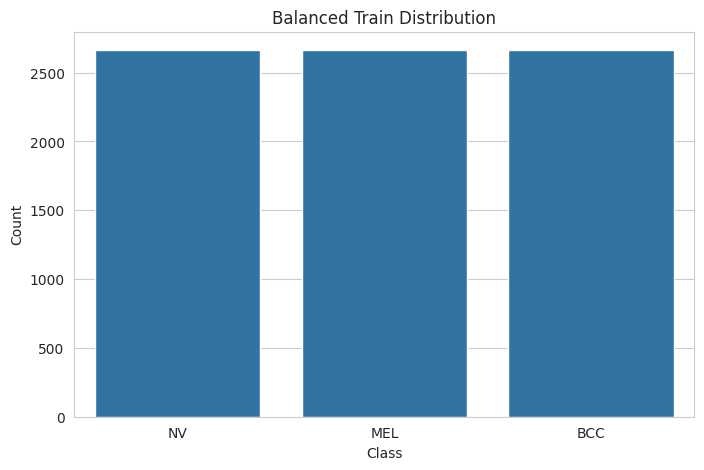

In [111]:
# Balanced Train Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_train_bal,
    x='target',
    order=df_train_bal['target'].value_counts().index
)

plt.title("Balanced Train Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

### Leakage Analysis

In [112]:
# Leakage Check

train_lesions = set(train_df['lesion_id'])

val_lesions = set(val_df['lesion_id'])

test_lesions = set(test_df['lesion_id'])

print(
    "Train-Val Leakage:",
    len(train_lesions & val_lesions)
)

print(
    "Train-Test Leakage:",
    len(train_lesions & test_lesions)
)

print(
    "Val-Test Leakage:",
    len(val_lesions & test_lesions)
)

Train-Val Leakage: 0
Train-Test Leakage: 0
Val-Test Leakage: 0


**Insight:**

- Proses undersampling dilakukan pada masing-masing subset dataset (train, validation, dan test) untuk menghasilkan distribusi class yang seimbang dengan rasio 1:1:1.

- Strategi balancing dilakukan setelah proses splitting untuk menjaga integritas validation dan test set serta mencegah data leakage antar subset dataset.

- Pendekatan undersampling membantu mengurangi dominasi kelas mayoritas sehingga model AI dapat mempelajari pola klasifikasi secara lebih adil pada seluruh kategori penyakit kulit.

## Dataset Modeling

In [113]:
# AI Modeling Dataframe

ai_columns = [

    'image_path',
    'target',
    'image',
    'anatom_site_general',
    'lesion_id',
    'site_risk_score'
]

train_ai_df = df_train_bal[
    ai_columns
].copy()

val_ai_df = df_val_bal[
    ai_columns
].copy()

test_ai_df = df_test_bal[
    ai_columns
].copy()

In [114]:
train_ai_df = train_ai_df.rename(columns={

    'target' : 'class_name',

    'image' : 'image_id'
})

val_ai_df = val_ai_df.rename(columns={

    'target' : 'class_name',

    'image' : 'image_id'
})

test_ai_df = test_ai_df.rename(columns={

    'target' : 'class_name',

    'image' : 'image_id'
})

In [115]:
train_ai_df.columns

Index(['image_path', 'class_name', 'image_id', 'anatom_site_general',
       'lesion_id', 'site_risk_score'],
      dtype='object')

In [116]:
train_ai_df.head()

,image_path,class_name,image_id,anatom_site_general,lesion_id,site_risk_score
0,/content/drive/MyDrive/DermaSight-DS/isic_2019...,NV,ISIC_0028440,lower extremity,HAM_0001461,0.5
1,/content/drive/MyDrive/DermaSight-DS/isic_2019...,MEL,ISIC_0015180_downsampled,head/neck,unknown_lesion_1841,0.8
2,/content/drive/MyDrive/DermaSight-DS/isic_2019...,MEL,ISIC_0032975,posterior torso,HAM_0001647,0.7
3,/content/drive/MyDrive/DermaSight-DS/isic_2019...,MEL,ISIC_0061833,head/neck,BCN_0004601,0.8
4,/content/drive/MyDrive/DermaSight-DS/isic_2019...,BCC,ISIC_0072060,head/neck,BCN_0000332,0.8


In [117]:
train_ai_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7992 entries, 0 to 7991
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   image_path           7992 non-null   object 
 1   class_name           7992 non-null   object 
 2   image_id             7992 non-null   object 
 3   anatom_site_general  7992 non-null   object 
 4   lesion_id            7992 non-null   object 
 5   site_risk_score      7992 non-null   float64
dtypes: float64(1), object(5)
memory usage: 374.8+ KB


In [118]:
print(
    "Train Shape:",
    train_ai_df.shape
)

print(
    "Validation Shape:",
    val_ai_df.shape
)

print(
    "Test Shape:",
    test_ai_df.shape
)

Train Shape: (7992, 6)
Validation Shape: (999, 6)
Test Shape: (978, 6)


In [119]:
print("\nMissing Values Check")

print("\nTrain")
print(train_ai_df.isnull().sum())

print("\nValidation")
print(val_ai_df.isnull().sum())

print("\nTest")
print(test_ai_df.isnull().sum())


Missing Values Check

Train
image_path             0
class_name             0
image_id               0
anatom_site_general    0
lesion_id              0
site_risk_score        0
dtype: int64

Validation
image_path             0
class_name             0
image_id               0
anatom_site_general    0
lesion_id              0
site_risk_score        0
dtype: int64

Test
image_path             0
class_name             0
image_id               0
anatom_site_general    0
lesion_id              0
site_risk_score        0
dtype: int64


**Insight**

- Dataset modeling berhasil dipisahkan ke dalam subset train, validation, dan test sehingga proses pengembangan model dapat dilakukan secara lebih terstruktur serta mengurangi risiko data leakage selama proses evaluasi.

- Kolom yang digunakan pada tahap modeling difokuskan pada informasi penting seperti `image_path`, `class_name`, `image_id`, `anatom_site_general`, `lesion_id`, dan `site_risk_score` yang mendukung proses klasifikasi citra kulit serta pemanfaatan metadata pasien.

- Kolom `lesion_id` tetap dipertahankan untuk menjaga konsistensi identitas lesi dan mendukung proses leakage-aware splitting, mengingat satu lesi dapat memiliki lebih dari satu citra pada dataset.

- Fitur `site_risk_score` disertakan sebagai representasi numerik tingkat risiko lokasi anatomi lesi yang dapat dimanfaatkan sebagai metadata tambahan pada proses modeling AI dan perhitungan severity scoring.

- Proses renaming kolom dari `target` menjadi `class_name` serta `image` menjadi `image_id` dilakukan untuk meningkatkan keterbacaan dan menjaga konsistensi struktur dataset pada tahap pengembangan model.

- Distribusi jumlah data menunjukkan bahwa subset train memiliki jumlah data paling besar dibandingkan validation dan test set sehingga model memiliki data yang cukup untuk proses pembelajaran.

- Hasil pemeriksaan menunjukkan seluruh dataset modeling tidak memiliki missing value sehingga siap digunakan pada tahap pengembangan model klasifikasi kanker kulit berbasis AI.

## Export Dataset

In [120]:
# Export Dataset

train_ai_df.to_csv(
    'train.csv',
    index=False
)

val_ai_df.to_csv(
    'val.csv',
    index=False
)

test_ai_df.to_csv(
    'test.csv',
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


In [121]:
files.download('train.csv')
files.download('val.csv')
files.download('test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Dataset Summary

In [122]:
summary_df = pd.DataFrame({

    'Dataset': [

        'train',

        'val',

        'test'

    ],

    'Rows': [

        len(train_ai_df),

        len(val_ai_df),

        len(test_ai_df)

    ],

    'Classes': [

        train_ai_df['class_name'].nunique(),

        val_ai_df['class_name'].nunique(),

        test_ai_df['class_name'].nunique()

    ]
})

summary_df

,Dataset,Rows,Classes
0,train,7992,3
1,val,999,3
2,test,978,3


**Insight:**

- Dataset berhasil dipisahkan ke dalam subset `train`, `val`, dan `test` menggunakan pendekatan leakage-aware splitting berbasis `lesion_id` sehingga gambar dari lesi yang sama tidak tersebar ke subset yang berbeda.

- Proses undersampling dilakukan setelah pembagian data untuk menghasilkan distribusi kelas yang lebih seimbang pada masing-masing subset tanpa menimbulkan risiko data leakage.

- Dataset modeling telah difokuskan pada informasi penting yang terdiri dari `image_path`, `class_name`, `image_id`, `anatom_site_general`, `lesion_id`, dan `site_risk_score` guna mendukung kebutuhan pengembangan model AI klasifikasi kanker kulit.

- Seluruh subset dataset telah bersih dari missing value dan memiliki struktur data yang konsisten sehingga siap digunakan pada tahap training, validation, dan testing model.

- Final dataset summary menunjukkan bahwa setiap subset masih mempertahankan ketiga kelas target (MEL, NV, dan BCC), sehingga proses pembelajaran dan evaluasi model dapat dilakukan secara representatif.

- Tahap data preparation menghasilkan dataset yang lebih terstruktur, seimbang, dan siap digunakan pada proses pengembangan model AI klasifikasi kanker kulit berbasis citra medis.

## Data Dictionary

In [123]:
# Data Dictionary

data_dictionary = pd.DataFrame({

    'Column Name': [

        'image_path',

        'class_name',

        'image_id',

        'anatom_site_general',

        'lesion_id',

        'site_risk_score'

    ],

    'Description': [

        'Path lokasi file citra medis',

        'Label kelas penyakit kulit (MEL, NV, BCC)',

        'Unique identifier untuk setiap gambar',

        'Lokasi anatomi umum tempat lesi berada',

        'Unique identifier untuk setiap lesi kulit',

        'Skor numerik risiko berdasarkan lokasi anatomi lesi'

    ],

    'Data Type': [

        'object',

        'object',

        'object',

        'object',

        'object',

        'float64'

    ]

})

data_dictionary

,Column Name,Description,Data Type
0,image_path,Path lokasi file citra medis,object
1,class_name,"Label kelas penyakit kulit (MEL, NV, BCC)",object
2,image_id,Unique identifier untuk setiap gambar,object
3,anatom_site_general,Lokasi anatomi umum tempat lesi berada,object
4,lesion_id,Unique identifier untuk setiap lesi kulit,object
5,site_risk_score,Skor numerik risiko berdasarkan lokasi anatomi...,float64


Data dictionary disusun berdasarkan dataset modeling final yang telah melalui proses data preparation dan akan digunakan pada tahap pengembangan model AI. Dokumentasi ini membantu memastikan setiap fitur memiliki definisi yang jelas dan konsisten selama proses pengolahan data maupun pengembangan sistem.

**Insight:**

- Data dictionary memberikan dokumentasi yang jelas mengenai struktur dataset modeling final yang digunakan pada proyek DermaSight.

- Informasi berupa nama kolom, deskripsi fitur, dan tipe data membantu meningkatkan pemahaman terhadap karakteristik dataset sebelum digunakan pada proses training, validation, dan testing model AI.

- Dataset modeling terdiri atas fitur identifikasi citra (`image_path`, `image_id`), label kelas (`class_name`), metadata lesi (`anatom_site_general`, `lesion_id`), serta fitur hasil feature engineering (`site_risk_score`).

- Fitur `site_risk_score` bertipe numerik (`float64`) dan digunakan untuk merepresentasikan tingkat risiko relatif berdasarkan lokasi anatomi lesi sehingga dapat dimanfaatkan pada proses modeling AI.

- Keberadaan data dictionary membantu meningkatkan konsistensi, keterbacaan, serta mempermudah proses pengelolaan dataset pada tahap analisis, pengembangan model, maupun deployment sistem.

# Conclusion

**Proyek DermaSight** berhasil melakukan analisis dataset penyakit kulit menggunakan dataset **ISIC_2019** dengan fokus pada tiga kelas utama, yaitu Melanoma (MEL), Melanocytic Nevi (NV), dan Basal Cell Carcinoma (BCC). Tahapan data science telah dilakukan secara sistematis mulai dari business understanding, data wrangling, exploratory data analysis (EDA), preprocessing, feature engineering, visualization & explanatory analysis, hingga data preparation untuk mendukung kebutuhan pengembangan model AI klasifikasi kanker kulit.

Hasil analisis menunjukkan bahwa setiap kelas penyakit memiliki karakteristik yang berbeda berdasarkan metadata pasien. Melanoma (MEL) dan Basal Cell Carcinoma (BCC) lebih banyak ditemukan pada kelompok usia dewasa hingga lansia dan dikategorikan sebagai kelompok berisiko tinggi (high risk), sedangkan Melanocytic Nevi (NV) mendominasi dataset dan termasuk kategori berisiko rendah (low risk). Selain itu, lokasi anatomi lesi juga menunjukkan pola distribusi yang berbeda pada setiap kelas penyakit sehingga menjadi salah satu informasi penting dalam analisis karakteristik kanker kulit.

Tahapan preprocessing berhasil menangani missing value, melakukan encoding pada fitur kategorikal, serta mempersiapkan data yang lebih konsisten untuk proses analisis. Selanjutnya, feature engineering menghasilkan fitur tambahan seperti `age_group`, `risk_category`, dan `site_risk_score` yang membantu meningkatkan representasi metadata pasien. Khususnya, fitur `site_risk_score` dikembangkan untuk merepresentasikan tingkat risiko relatif berdasarkan lokasi anatomi lesi dan dipersiapkan sebagai metadata numerik yang dapat dimanfaatkan pada proses modeling AI.

Pada tahap data preparation, dataset dibagi menggunakan pendekatan leakage-aware splitting berbasis `lesion_id` untuk memastikan gambar dari lesi yang sama tidak tersebar ke subset train, validation, dan test. Setelah proses pembagian data, dilakukan undersampling pada masing-masing subset untuk mengurangi ketidakseimbangan distribusi kelas tanpa menimbulkan risiko data leakage.

Secara keseluruhan, proyek DermaSight berhasil menghasilkan dataset yang lebih bersih, terstruktur, terdokumentasi, dan siap digunakan pada tahap pengembangan model AI klasifikasi kanker kulit berbasis citra medis.

# Insight

- Dataset ISIC_2019 menyediakan kombinasi citra medis dan metadata pasien yang mendukung analisis karakteristik penyakit kulit berbasis AI.

- Distribusi kelas menunjukkan adanya class imbalance dengan dominasi kelas Melanocytic Nevi (NV), sehingga diperlukan strategi balancing sebelum proses modeling.

- Faktor usia dan lokasi anatomi lesi menunjukkan pola distribusi yang berbeda pada setiap kelas penyakit dan berpotensi menjadi informasi pendukung dalam proses klasifikasi.

- Proses preprocessing berhasil menangani missing value serta mengubah fitur kategorikal menjadi representasi yang lebih terstruktur untuk kebutuhan analisis dan modeling.

- Feature engineering menghasilkan fitur tambahan berupa `age_group`, `risk_category`, dan `site_risk_score` yang membantu memperkaya representasi metadata pasien.

- Penerapan leakage-aware splitting berbasis `lesion_id` membantu mengurangi risiko kebocoran informasi antar subset train, validation, dan test.

- Proses undersampling menghasilkan distribusi kelas yang lebih seimbang sehingga dapat membantu mengurangi bias model terhadap kelas mayoritas.

- Dataset modeling akhir berhasil dipersiapkan dalam format yang lebih terstruktur dan siap digunakan pada tahap pengembangan model AI klasifikasi kanker kulit.

# Recommendation

- Mengembangkan model deep learning berbasis CNN atau transfer learning untuk melakukan klasifikasi citra penyakit kulit secara otomatis.

- Melakukan evaluasi performa model menggunakan metrik seperti accuracy, precision, recall, F1-score, ROC-AUC, dan confusion matrix.

- Mengeksplorasi pemanfaatan metadata tambahan seperti `site_risk_score` untuk meningkatkan performa model dan mendukung interpretasi hasil prediksi.

- Mengembangkan sistem severity scoring yang mengombinasikan hasil prediksi model dengan metadata pasien untuk mendukung analisis risiko secara lebih komprehensif.

- Mengembangkan dashboard interaktif berbasis Streamlit untuk menampilkan visualisasi dataset, hasil prediksi, dan informasi risiko secara real-time.
